# Preliminary Analysis — the labelled eVTOL patent data set

This notebook produces the *Preliminary Analysis* document node by node: chapter 1 to 4, three
numbering levels (`2.1`, `2.1.1`), every table and figure named by the subsection that owns it.
The structure and the prose live in `src/dataset_facts/index.py`; every number in the prose is a
placeholder filled from `numbers.live(ds)` at run time, and the three schemes (document pipeline,
refinement funnel, design-space order) are SVG files whose numbers are interpolated the same way,
so a figure can never disagree with the table beside it.

**Source of the labels** is the `dataset_facts.source` switch in `config.yaml`: `batch_xlsx` reads
`labels/reviewed_patents_Batch_0N.xlsx` and the per-batch identity workbooks directly; `master_04`
reads notebook 04's join. Same tables either way. A review of several labelling decisions is still
open, so some counts will move; the structure does not depend on which way they move.

Thin notebook: it only **imports**, **calls** `src/dataset_facts/`, and **displays**. `show(id)` prints
a node's prose with the live numbers and the figures it owns; the code under it produces its tables.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / 'config.yaml').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, Image, SVG, display

from src.config_loader import load_config
from src.dataset_facts import (load_dataset, a1, a2, a3, a4, a5, a6, roster, rules, index,
                               figures, numbers, report, published, export, ch5)

pd.set_option('display.width', 200)
pd.set_option('display.max_colwidth', 90)
pd.set_option('display.max_rows', 250)

cfg = load_config()
F = cfg['dataset_facts']
OUT = ROOT / F['output_dir']
PARTIAL = F.get('partial_window_start', 2024)
ds = load_dataset(cfg)

print('source:', ds.source, '|', ds.root)
if ds.build_log: print('batch reader:', {k: v for k, v in ds.build_log.items() if k != 'dup_root_missing'})
ds.counts

source: master_04 | /mnt/storage_11tb/Drive_files_to_syncronize/3 - Images DataSets & Labelling Outputs/1639_LABELLED


{'patents_acquired': 1639,
 'patents_wizard_approved': 1110,
 'patents_approved': 935,
 'patents_gated_out': 175,
 'variants_gated_out': 194,
 'primary_variants_gated_out': 122,
 'patents_analysis': 585,
 'approved_variants': 1027,
 'primary_approved_variants': 677,
 'approved_figures': 1628,
 'approved_figures_all': 1649,
 'detail_figures': 21}

The analysis unit is the **unique aircraft** (`ds.variants`, one row per aircraft; O1 / O2 observations
excluded, S3 similars included). Patent-level facts use `ds.patents` (all acquired) or
`ds.patents_analysis` (the representative primary patents); image-level facts use `ds.approved_figures`.
The labelling batches are provenance only — nothing is split by batch.

In [2]:
N = numbers.live(ds, PARTIAL)          # every number the prose and the diagrams quote
FIGS = figures.render_all(ds, OUT, PARTIAL)   # PNG charts + the three SVG schemes -> outputs/.../figures
plt.close('all')

def show(node_id):
    """Heading, level line, prose (numbers filled in) and the figures of one node."""
    n = index.node(node_id)
    parts = [index.heading(node_id, N).replace('## Chapter', '### Chapter')]
    if index.level_line(node_id): parts.append(index.level_line(node_id))
    if index.text(node_id, N): parts.append(index.text(node_id, N))
    display(Markdown('\n\n'.join(parts)))
    for name in n.get('figures', []):
        p = FIGS[name]
        display(SVG(filename=str(p)) if p.suffix == '.svg' else Image(filename=str(p), width=760))
    if index.after(node_id, N): display(Markdown(index.after(node_id, N)))

{k: v.shape for k, v in {
    'master (patent, variant)': ds.master,
    'aircraft observations': ds.approved_variants,
    'unique aircraft - the analysis unit': ds.variants,
    'patents acquired': ds.patents,
    'representative primary patents': ds.patents_analysis,
    'approved figures': ds.approved_figures,
    'identity (Stage 03a)': ds.identity,
}.items()}

/home/vasco/Vasco Workspace/Tese_Vasco_Lnx/eVTOL-Visual-Evaluation/labeling_evaluation/src/dataset_facts/numbers.py:203: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  n["flagship_match"] = int(pub["top label matches a public type"].fillna(False).astype(bool).sum())


/home/vasco/Vasco Workspace/Tese_Vasco_Lnx/eVTOL-Visual-Evaluation/labeling_evaluation/src/dataset_facts/numbers.py:203: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  n["flagship_match"] = int(pub["top label matches a public type"].fillna(False).astype(bool).sum())


{'master (patent, variant)': (1750, 495),
 'aircraft observations': (1027, 494),
 'unique aircraft - the analysis unit': (677, 494),
 'patents acquired': (1639, 494),
 'representative primary patents': (585, 494),
 'approved figures': (1628, 53),
 'identity (Stage 03a)': (1639, 164)}

---
## Chapter 1 — Introduction

### Chapter 1 — Introduction

This document is the first pass over the labelled eVTOL patent data set: what was acquired, what survived each refinement, and how the labels spread. Every number in it is computed from the consolidated master sheet (Stage 04), which joins the five batch exports with the identity review. A review of several labelling decisions is still open, so some counts will move; the structure of the analysis does not depend on which way they move.

Chapter 2 settles what enters and at which level. Three refinements take 1 639 acquired patents to 935 representative patents, 677 unique aircraft and 1 628 whole-aircraft figures. It comes first because every later count is a count of something it defines.

Chapter 3 describes the data set one level at a time: provenance at the patent level, the drawing labels at the image level and the design space at the unique-aircraft level. It comes second because its tables are the spread the next chapter judges.

Chapter 4 asks whether the labels can be trusted. For now it compares what is already known publicly with what the methodology recovered. Validity can only be judged once the spread of the labels is known, which is why it follows chapter 3.

Chapter 5 specifies the design space and evolution analysis. It comes last because every setting it fixes is a value read from a table of chapters 2 to 4.

**Levels of analysis.** The document works at three levels and every section states which one it uses before its first table: the patent (1 639 acquired, 935 representative), the unique aircraft (677) and the image (1 628 approved whole-aircraft figures). A statistic computed at one level does not transfer to another.

**Terms.** A *representative patent* shows an eVTOL aircraft **and** that aircraft can be read from its figures, where eVTOL means electric, vertical take-off and occupied: an aircraft the review tagged as UAV-similar, not electric or STOL-only is near the boundary but outside it, and leaves. *Granted* and *pending application* are the office's words and never describe representativity. A *unique aircraft* is one design, however many patents draw it. The same aircraft seen again is an *observation* (O1 with new figures, O2 with the same figures); a *similar* (S3) is a different aircraft and is counted as one new unique aircraft.

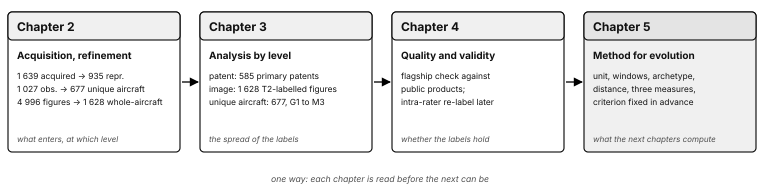

In [3]:
show('1')

*Note from the annotated index v1.1 (2026-09-09), kept verbatim — section numbers are the old index's:*

# Preliminary Analysis — the labelled dataset, index order

This notebook follows the annotated index of the *Preliminary Analysis* document section by
section (1.1 → 5.5, then the additions). Each section is a markdown cell with the index's three
lines — **Source**, **Tables / figures**, **Gives →** — followed by the code that produces exactly
those tables and figures. The index text lives in `src/dataset_facts/index.py`; the notebook, the
block diagrams and the generated draft all read it from there.

The document states numbers; this notebook is where they come from. Change the labels, re-run
`Patent-Labelling-Tools/notebooks/04_master_labels.ipynb`, re-run this, and every table, figure and
the draft `PRELIMINARY_ANALYSIS.md` move with the data.

Thin notebook: it only **imports**, **calls** `src/dataset_facts/`, and **displays**.

> Unit of analysis, stated once at first use (1.3): the primary approved aircraft variant (805) for design statistics; the patent (695 approved primary) for metadata and citation statistics.

*Note from the annotated index v1.1 (2026-09-09), kept verbatim — section numbers are the old index's:*

The analysis unit is the **primary approved variant** (`ds.variants`, one row per aircraft, D1/D2
duplicates excluded). Patent-level facts use `ds.patents` (all 1,639) or `ds.patents_analysis` (the
approved primary 695). The labelling batches are provenance only — nothing is split by batch.

*Note from the annotated index v1.1 (2026-09-09), kept verbatim — section numbers are the old index's:*

---
## Overview — what each section gives, and which chapter it feeds

The block diagram is drawn from `index.py`: one box per section with its short *Gives* line,
arrows to the chapters it feeds.

---
## Chapter 2 — eVTOL Data Sets: Acquisition and Refinement

### Chapter 2 — eVTOL Data Sets: Acquisition and Refinement

Three refinements, each at its own level, take the acquired patents to the analysis set. Refinement 1 decides which patents represent the domain, refinement 2 turns patents into unique aircraft, refinement 3 decides which figures the labels rest on.

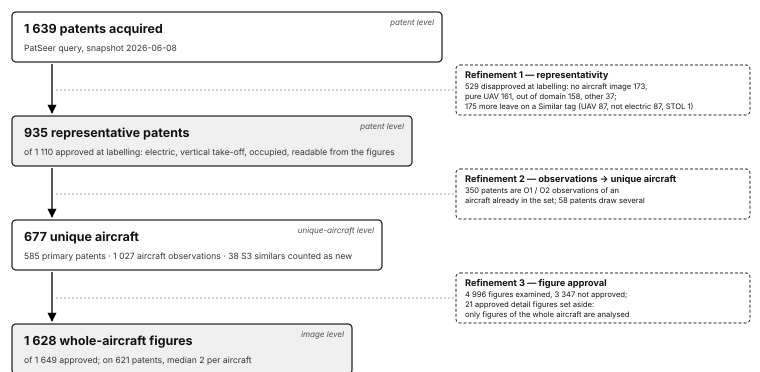

In [4]:
show('2')

*Note from the annotated index v1.1 (2026-09-09), kept verbatim — section numbers are the old index's:*

---
## 1. Patent dataset construction (→ Ch. 3)

In [5]:
show('2.1')

### 2.1 Refinement 1 — representativity

*Level of analysis: patent.*

A patent is representative when it shows an eVTOL aircraft and the aircraft can be read from its figures. The test is applied in two steps. At labelling, 529 of the 1 639 acquired patents are disapproved: no aircraft image, or an aircraft plainly outside the domain; 1 110 (68%) are approved. The identity review then reads the text of every approved patent for what a drawing cannot show, occupancy, powertrain and take-off mode, and marks the near misses with a tag: UAV-similar, electric-similar, STOL-similar. A tagged aircraft leaves the analysis set. 175 approved patents lose every aircraft this way, so 935 (57%) are representative.

In [6]:
show('2.1.1')
display(a2.d1_funnel(ds))
display(a2.d1_approval_by_region(ds))
a2.d1_rejection_reasons(ds)

#### 2.1.1 Disapproval reasons

The two largest reasons at labelling are the two conditions themselves: no aircraft image (173) and a domain miss (pure UAV 161, out of domain 158); the remaining 37 are marginal. The review adds the tagged near misses: UAV-similar 87, not electric 87, STOL-only 1.

,stage,count,note
0,Patents acquired (PatSeer query),1639,
1,Approved at labelling,1110,68% of acquired: show an aircraft that can be read from the figures
2,Representative patents,935,"175 approved patents leave on a Similar tag (UAV, not electric, STOL only): only elect..."
3,Representative patents that are the primary record,585,O1 / O2 observations removed
4,Aircraft observations,1027,"O1, O2 and S3 included"
5,Unique aircraft - the analysis unit,677,one row per aircraft
6,Approved figures,1649,show the aircraft in a readable view
7,Whole-aircraft figures - the analysis image set,1628,"21 approved detail figures set aside; on 621 patents, median 2 per patent"


,region,patents,representative,representative share
0,North America,719,436,0.61
1,Asia-Pacific,454,239,0.53
2,Europe,431,241,0.56
3,Middle East,20,8,0.40
4,South America,10,7,0.70
5,International (PCT),2,1,0.50
6,Unknown,2,2,1.00
7,Africa,1,1,1.00


,reason,patents
0,No Aircraft Image,173
1,Pure UAV,161
2,Out of Domain,158
3,Similar: UAV,87
4,Similar: not electric,87
5,Other,22
6,No Content,12
7,Not VTOL,3
8,Similar: STOL only,1


*Note from the annotated index v1.1 (2026-09-09), kept verbatim — section numbers are the old index's:*

### 1.1 Acquisition funnel

- **Source**: D1 (funnel table); supervisor's pipeline figure with Table 1.
- **Tables / figures**: funnel figure 1,639 acquired → 1,110 approved → 695 primary patents → 1,268 variants → 805 primary variants → 1,913 approved figures. Rejection-reason table. Approval rate by region table. Rejection reasons by region and by filer type (addition 2).
- **Gives →** the size of the analysis set at each level and why two thirds survived; the regional approval gap shows the query behaves differently by office, so region is reported next to every later statistic. Feeds: Ch. 3 sample description; Ch. 4 Provenance (region as a possible confounder).

*Note from the annotated index v1.1 (2026-09-09), kept verbatim — section numbers are the old index's:*

Rejection reasons by region and by filer type (addition 2): whether the labelling filter behaves
the same across offices and applicants.

In [7]:
show('2.1.2')
a2.d1_similars(ds)

#### 2.1.2 The similars: UAV-similar, STOL-similar, electric-similar

Three kinds of near miss sit next to the boundary and each is caught by a different mechanism, all of them from the text, because neither occupancy nor powertrain nor take-off mode can be read from a drawing. Each tag names an aircraft, not a patent: a patent that draws several aircraft keeps the ones without a tag. The tags remove 122 unique aircraft (86 UAV-similar, 37 electric-similar, 2 STOL-only; an aircraft can carry two tags). What stays is deliberate: V/STOL, where the text claims both modes, is a vertical take-off aircraft (87 patents); a hybrid powertrain has electric motors (171); and where the text gives no powertrain evidence either way (314 patents) the aircraft stays, because silence is not a turbine.

,similar,caught by,aircraft observations tagged,unique aircraft removed,patents tagged,patents losing every aircraft,outcome
0,UAV-similar,"tag UAVSimilar: drawn unoccupied, the text does not declare a UAV (a declared UAV is d...",86,86,73,73,leaves the analysis set at refinement 1
1,STOL-similar,"take-off mode read from the text, confirmed at review: STOL only (a patent that claims...",2,2,2,2,leaves the analysis set at refinement 1
2,Electric-similar,powertrain read from the text names a turbine or piston engine and no electric motor (...,37,37,32,31,leaves the analysis set at refinement 1


*Note from the annotated index v1.1 (2026-09-09), kept verbatim — section numbers are the old index's:*

### 1.2 Filing reasons and inclusion gates

- **Source**: A.1 (electric / VTOL / UAV columns), Part B lines G1–G3, rejection reasons of D1.
- **Tables / figures**: one table with the three gates (electric, take-off, UAV) as the machine left them and the state after review (`*_final` columns).
- **Gives →** which patents are eVTOL by rule and which were excluded, so the domain boundary is explicit. Feeds: Ch. 3 technological domain definition; the V/STOL ruling.

*Note from the annotated index v1.1 (2026-09-09), kept verbatim — section numbers are the old index's:*

`machine` is what Stage 03a decided; `after review` is the `*_final` column that carries the
annotator's decisions on top of it. The UAV hint and the UAV final use different vocabularies, so
they are listed side by side. First over all 1,639 patents, then over the 695 analysis patents.

In [8]:
show('2.1.3')
display(a2.d9_publication_lag(ds, 'region'))
a2.d9_publication_lag(ds, 'pub_office')

#### 2.1.3 Publication lag

A patent enters the corpus only when it publishes. The median lag from priority to publication is 1 to 2 years and the 90th percentile 3 in the three main regions, so priority years to 2022 are complete, the year after nearly, and 2024 onwards is truncated. Every trend statement ends at 2022 and the last window is drawn as partial. Priority year is the time axis because it is the date closest to the design decision.

,region,patents,median lag,90th percentile
0,North America,235,2.0,3.0
1,Asia-Pacific,171,1.0,3.0
2,Europe,164,2.0,3.0
3,South America,7,2.0,3.0
4,Middle East,4,2.0,4.0
5,Unknown,2,2.0,2.0
6,International (PCT),1,1.0,1.0
7,Africa,1,1.0,1.0


,pub_office,patents,median lag,90th percentile
0,US,339,2.0,3.0
1,CN,99,0.0,1.0
2,DE,34,1.0,2.0
3,WO,32,2.0,2.0
4,Other,26,1.0,2.0
5,EP,15,2.0,2.0
6,KR,14,2.0,2.0
7,GB,12,0.0,0.0
8,FR,10,2.0,2.0
9,IT,2,2.0,2.0


*Note from the annotated index v1.1 (2026-09-09), kept verbatim — section numbers are the old index's:*

### 1.5 Filing-to-publication lag and the right-censoring cut

- **Source**: D9 (lag table), Part E.2.
- **Tables / figures**: median and 90th-percentile lag by region and by office. Snapshot date.
- **Gives →** priority years to 2022 are complete, 2023 nearly, 2024–2026 truncated; every trend claim ends at 2023 and the last window is drawn as partial. This is what selects the patents that enter the G1–M3 analysis. Priority year is the time axis because it is the date closest to the design decision; application and publication years lag it by office-dependent amounts. Feeds: Ch. 3 corpus boundary; Ch. 5 window definition inherits the cut, does not re-derive it.

In [9]:
show('2.1.4')
a2.d1_filing_status(ds)

#### 2.1.4 Filing status

Granted and pending are the office's decision on the claims, not on the drawing, so they do not touch representativity. The analysis runs on every representative patent; filing status is carried as a stratum. Of the 585 primary patents, 378 were granted, 94 are pending applications and 113 were withdrawn, refused or suspended.

Refusal and withdrawal are legal or procedural outcomes (novelty, inventive step, clarity, unpaid fees), not a verdict on the aircraft drawn. Hence:

- **Pool everything, carry status as a stratum.**
- **Do not filter to granted.** Status is confounded with filing year.
- **Use it as a robustness check, not a filter.** Filing status against top-level architecture.
- **Sensitivity line.** Headline counts repeated on the 378 granted primaries.
- **Status is a snapshot** at the acquisition date.

,filing status,acquired,representative,primary
0,"Granted, in force",888,539,299
1,"Granted, since lapsed",221,98,79
2,Pending application,240,150,94
3,"Withdrawn, refused or suspended",290,148,113


In [10]:
show('2.2')

### 2.2 Refinement 2 — observations to unique aircraft

*Level of analysis: patent → unique aircraft.*

The 935 representative patents hold 1 027 aircraft observations. Observations of an aircraft already in the set are removed, and a patent that draws several aircraft contributes one row per aircraft. The result is 677 unique aircraft on 585 primary patents.

In [11]:
show('2.2.1')
display(a2.d7_duplicates(ds))
pd.Series(a2.d7_d3_identical_to_root(ds)).to_frame('value')

#### 2.2.1 Same unique aircraft in different patents: O1, O2, S3

O1 and O2 are the same aircraft seen again; their labels are inherited from the original and they add no unique aircraft. S3 is a similar aircraft, relabelled in full, and counts as one new unique aircraft. 15 of the 38 S3 rows are identical to their original on all seven archetype fields; that double-count is kept as a sensitivity run.

,type,what it is,observations,unique aircraft added,new unique aircraft
0,"O1 - same aircraft seen again, new figures",labels inherited from the original,41,0,no
1,"O2 - same aircraft, same figures",nothing relabelled,381,0,no
2,S3 - a similar aircraft,fully relabelled; one new unique aircraft,38,32,yes


,value
d3_rows,32.000
same_architecture_as_root,30.000
identical_on_all_archetype_fields,15.000
share_of_analysis_set,0.022


*Note from the annotated index v1.1 (2026-09-09), kept verbatim — section numbers are the old index's:*

### 1.3 Unit of analysis: unique aircraft, repeated observations, several aircraft per patent

- **Source**: D7 (duplicate types), aircraft-per-patent table, Part E.1.
- **Tables / figures**: duplicate table (D1 same aircraft new figures · D2 same aircraft same figures · D3 same invention modified, with the count identical to root at A1). Aircraft drawn per patent.
- **Gives →** how many independent aircraft there are and how the unit choice changes N; the double-count at A1 is stated with a number and kept as a sensitivity run. Feeds: every count in Ch. 4 and Ch. 5; the unit decision (G.4 #1).

In [12]:
show('2.2.2')
a2.d7_aircraft_per_patent(ds)

#### 2.2.2 Different unique aircraft in the same patent

58 of the 585 primary patents draw more than one aircraft, up to 5; each is a row of its own.

,aircraft drawn in the patent,patents
0,1,527
1,2,38
2,3,9
3,4,8
4,5,3


In [13]:
show('2.3')

### 2.3 Refinement 3 — figure approval

*Level of analysis: unique aircraft → image.*

Each figure of a representative patent is approved or not on its own, and of the approved figures only those that show the whole aircraft are analysed. 1 649 figures are approved; 1 628 show the whole aircraft and form the image set; the other 21 are detail figures approved on purpose (tilt mechanism, rotor), kept on record and not analysed. Every image-level count in this document, and the number of figures behind each aircraft, is taken on the whole-aircraft figures.

In [14]:
show('2.3.1')
display(a2.d11_figure_approval(ds))
a2.d11_figure_quality(ds)

#### 2.3.1 Reasons to approve a figure, and the resulting count

A figure is approved when it shows the aircraft in a view the architecture can be read from. The 935 representative patents hold 4 996 figures with an image file; 1 649 pass; 1 628 of them show the whole vehicle and enter the analysis, the other 21 are detail figures approved on purpose (tilt mechanism, rotor) and are set aside.

,figures,count
0,Figures with an image file,4996
1,Not approved,3328
2,Approved,1649
3,"approved, shows: Whole Vehicle Layout",1628
4,"approved, shows: Tilt Hinge/Mechanism",12
5,"approved, shows: Rotor/Propeller Blade",5
6,"approved, shows: other part or blank (2 values)",4


,approved figures,count
0,Clean,1617
1,Partial quality,7
2,Poor quality,4
3,Labelled Whole Vehicle Layout,1628
4,Total approved figures,1628


In [15]:
show('2.3.2')
a2.d11_figure_patents(ds)

#### 2.3.2 Why 621 patents carry figures and only 585 are primary records

621 patents carry approved figures but only 585 are primary records. 36 are O1 observations, which bring new figures of an aircraft already in the set. The counts are in `tables/a2_d11_figure_patents.csv`.

,patents,count,note
0,Patents carrying approved figures,621,
1,primary representative patents,585,the analysis set
2,O1 observations with new figures,36,same aircraft as a primary record; labels inherited
3,"other representative, not primary",0,
4,disapproved patents with an approved figure,0,


---
## Chapter 3 — Data Set Analysis by Level

In [16]:
show('3')

### Chapter 3 — Data Set Analysis by Level

One level at a time: the patent for provenance, the image for the drawing labels, the unique aircraft for the design space.

In [17]:
show('3.1')

### 3.1 Provenance

*Level of analysis: patent.*

*Note from the annotated index v1.1 (2026-09-09), kept verbatim — section numbers are the old index's:*

---
## 3. Provenance (→ Ch. 4 Provenance)

#### 3.1.1 Region, assignee country, publication office

North America supplies 44% of the acquired patents and has the highest representative share (0.61); Asia-Pacific and Europe are acquired in similar numbers but less often show a whole aircraft (0.53, 0.56). The query behaves differently by office, so region is reported next to later statistics as a stratum and never used as a filter.

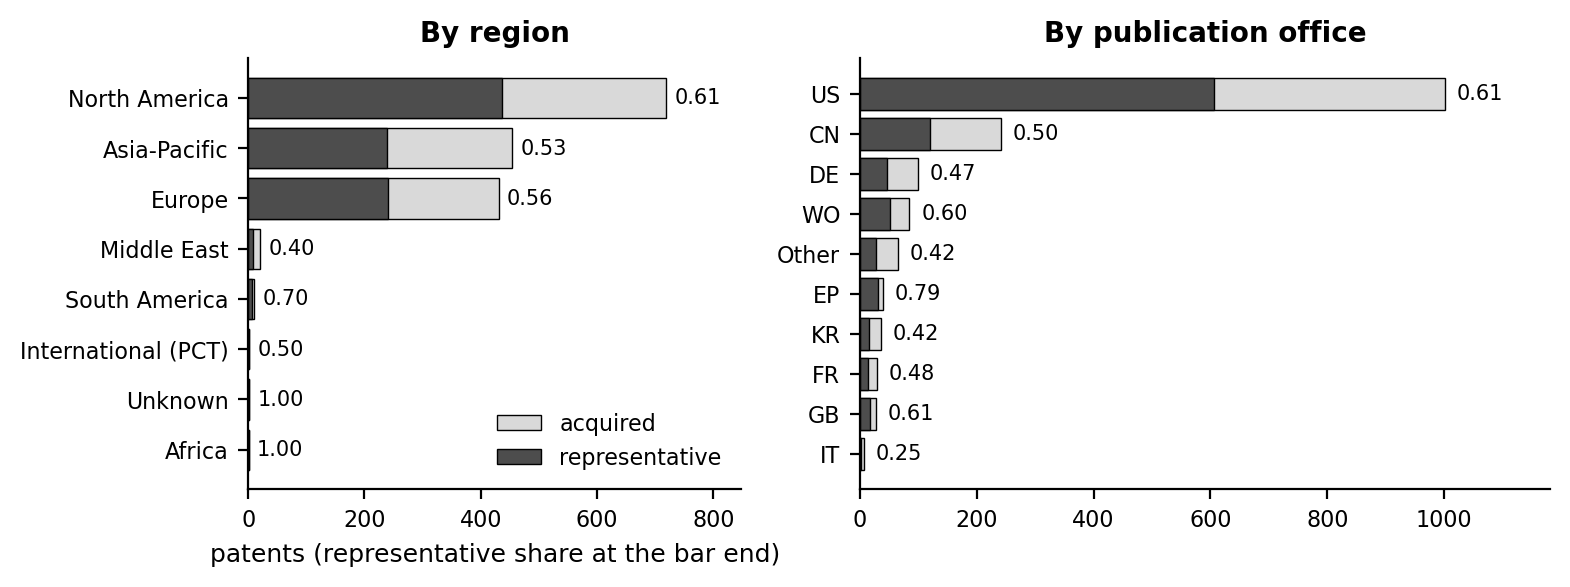

,region,patents,representative,representative share
0,North America,719,436,0.61
1,Asia-Pacific,454,239,0.53
2,Europe,431,241,0.56
3,Middle East,20,8,0.40
4,South America,10,7,0.70
5,International (PCT),2,1,0.50
6,Unknown,2,2,1.00
7,Africa,1,1,1.00


,assignee_country,patents,representative,representative share
0,US,651,402,0.62
1,CN,267,131,0.49
2,DE,188,112,0.60
3,JP,95,67,0.71
4,KR,60,25,0.42
5,FR,58,25,0.43
6,GB,43,26,0.60
7,RU,40,14,0.35
8,IT,28,22,0.79
9,CA,26,19,0.73


,pub_office,patents,representative,representative share
0,US,1001,606,0.61
1,CN,241,121,0.50
2,DE,100,47,0.47
3,WO,85,51,0.60
4,Other,66,28,0.42
5,EP,39,31,0.79
6,KR,36,15,0.42
7,FR,29,14,0.48
8,GB,28,17,0.61
9,IT,8,2,0.25


In [18]:
show('3.1.1')
prov = a1.provenance_tables(ds)
display(prov['region'])
display(prov['assignee_country'])
prov['pub_office']

*Note from the annotated index v1.1 (2026-09-09), kept verbatim — section numbers are the old index's:*

### 3.1 Region, assignee country, publication office

- **Source**: A.1 metadata (region, assignee_country, pub_office), D1 by region.
- **Tables / figures**: region table; assignee-country table; publication-office table; one bar chart.
- **Gives →** where the corpus comes from and where the acquisition surplus sits (US whole-aircraft filings vs drone and component filings elsewhere). Feeds: Ch. 4 region as a stratum, never as a filter (G.4 #6).

In [19]:
show('3.1.2')
display(a2.d8_filer_mix(ds))
display(a2.d8_concentration(ds))
display(a2.d8_split_firms(ds, 'Bell / Textron'))
a5.name_proposals(ds)

#### 3.1.2 Who filed, and how concentrated it is

The three rows of the first table are read as follows. *Individual inventors* are patents whose assignee is a person rather than an organisation, as the identity stage resolved it (182). *Unattributed or independent* holds the patents with no assignee string, or one that resolves to no known company (127). *Named companies* are the 85 firms of the canonical company column; a firm is counted once across every assignee string it files under, which is why Bell / Textron is 52 patents on the canonical column and 25 on its largest raw string. 53% of the corpus is not corporate, and concentration is mild (HHI 0.006 on the raw string), so pseudo-replication matters mainly where one firm dominates a class. Name proposals exist for 385 patents (349 from a company gazetteer, 36 from the text); none is verified, and a company-attributed name is a statement about the assignee, not about the drawing.

,filer,patents,share
0,Individual inventors,182,0.31
1,Unattributed or independent,127,0.22
2,Named companies (85 of them),276,0.47


,concentration measure,on the raw assignee string,on the canonical company
0,Distinct filers,390,87 values: 85 named companies plus the two catch-all buckets
1,Filers with exactly one patent,318,36 of the 85 named companies
2,Top-10 share of all 585 patents,0.18,0.23 (named companies only)
3,HHI,0.006,0.011 (named companies only)
4,Largest filer,"BELL HELICOPTER TEXTRON INC, 25","Bell / Textron, 52"


,assignee string,patents
0,BELL HELICOPTER TEXTRON INC,25
1,BELL TEXTRON INC,17
2,TEXTRON INNOVATIONS INC,8
3,AAI CORP,1
4,TEXTRON SYSTEM CORP,1


,value,count,share,name appears in the patent's own text
0,gazetteer,349,0.91,No 349
1,sbert,36,0.09,Yes 36


*Note from the annotated index v1.1 (2026-09-09), kept verbatim — section numbers are the old index's:*

### 3.2 Who filed and how concentrated it is

- **Source**: D8, plan line G8 (assignee type).
- **Tables / figures**: filer-type table; concentration table on raw string vs canonical company; single-patent filers; the strings one firm files under; Lorenz curve.
- **Gives →** half the corpus is not corporate, which is what makes the assignee-type stratum worth building; concentration is mild, so pseudo-replication matters mainly in the tilt-rotor class. Feeds: Ch. 4 Provenance (assignee type); Ch. 5 company bootstrap and within-company permutation. Still to produce: the `assignee_type` column (G8).

*Note from the annotated index v1.1 (2026-09-09), kept verbatim — section numbers are the old index's:*

The `assignee_type` column (G8) does not exist yet; the suffix heuristic below only shows the size
of the prize and is not a variable to analyse.

#### 3.1.3 Publication timeline, overall and per region

Per-year counts before 2016 are too small for per-year statistics, so the analysis uses windows of three to five years, rarefied to about 40 aircraft each; the smallest complete window holds 69. The 2024–26 window is partial: it is drawn hatched and labelled, never dropped.

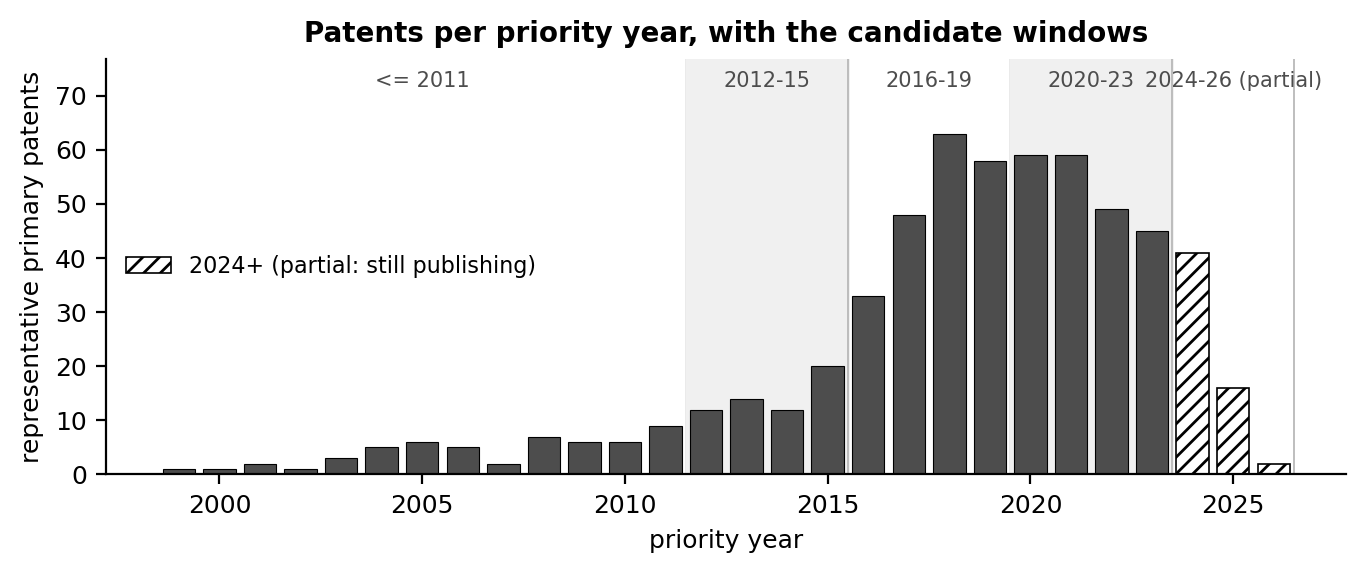

,era,years_present,patents,min_per_year,max_per_year
0,1999-2011,13,54,1,9
1,2012-2015,4,58,12,20
2,2016-2024,9,455,33,63
3,2025+,2,18,2,16


,window,unique aircraft
0,<= 2011,70
1,2012-15,69
2,2016-19,227
3,2020-23,250
4,2024-26 (partial),61


In [20]:
show('3.1.3')
display(a1.time_coverage_summary(ds))
a2.d9_architecture_by_window(ds)[['window', 'unique aircraft']]

*Note from the annotated index v1.1 (2026-09-09), kept verbatim — section numbers are the old index's:*

### 1.6 Publication timeline

- **Source**: A.1 time coverage, D9 counts.
- **Tables / figures**: patents per priority year, one bar chart; candidate windows with the variants each holds.
- **Gives →** per-year statistics before 2016 are noise, so windows of 3–5 years rarefied to n ≈ 40 are needed. Feeds: Ch. 5 window width and rarefaction n. Priority year is the time axis (closest to the design decision).

In [21]:
show('3.2')

### 3.2 Image analysis

*Level of analysis: image, T2 labels.*

*Note from the annotated index v1.1 (2026-09-09), kept verbatim — section numbers are the old index's:*

---
## 2. Image and labelling statistics (→ Ch. 3 labelling results; input to Ch. 6)

In [22]:
show('3.2.1')
a2.d2_figure_slots(ds)

#### 3.2.1 Answerable slots at image level

Every approved figure carries 8 T2 slots. They describe the drawing, not the design (perspective, style, colour, background, what is shown, flight state), and they are the confounds the embedding pillar has to control for. Only perspective and flight state vary; the rest are near-constant.

,name,field,answered,answers,top_share,effective_answers,most common answers
0,perspective,per,1628,7,0.49,4.1,Front-Isometric 793 · Top 331 · Side 268
1,drawing style,acSty,1628,3,0.95,1.2,Line Drawing 1553 · Render 68 · Draft 7
2,aircraft colour,acCol,1628,3,0.96,1.2,B/W (Monochrome) 1565 · Grayscale 56 · Full Color 7
3,background style,bgSty,1628,2,0.99,1.0,Solid Fill 1616 · Shaded/Gradient 12
4,what the figure shows,parts,1628,1,1.00,1.0,Whole Vehicle Layout 1628
5,quality flag,qualityFlag,1628,3,0.99,1.0,clean 1617 · generic 7 · poor_quality 4
6,flight state drawn,acState,1615,5,0.40,3.6,Invariant 642 · Hover 452 · Cruise 433
7,legends present,hasLegends,48,2,0.96,1.2,True 46 · False 2


*Note from the annotated index v1.1 (2026-09-09), kept verbatim — section numbers are the old index's:*

### 2.1 Answerable slots at patent and image level

- **Source**: D2 (label-set properties).
- **Tables / figures**: aircraft-level slot properties (slots, concepts, slots answered per aircraft, coverage, near-constant and informative counts); figure-level (T2) slots profiled over the approved figures.
- **Gives →** the 283 columns are slots, not concepts; sparsity is structural (boom groups, propulsor tiers), so absence is a design fact carried by the parent field. Feeds: the field shortlist for Ch. 4 and Ch. 5; the derived per-aircraft layer (D2b, see additions).

*Note from the annotated index v1.1 (2026-09-09), kept verbatim — section numbers are the old index's:*

Aircraft level first (the cut-offs come from `config.yaml`), then the figure-level (T2) slots the
wizard answers on every approved figure — these describe the drawing, not the design, and are the
confounds the embedding pillar has to control for. *Assumption for "image level" in the index:*
the T2 slots; say so if another reading was meant.

In [23]:
show('3.2.2')
display(a2.d11_figures_per_variant(ds))
pd.Series(a2.d11_sensitivity_set(ds)).to_frame('value')

#### 3.2.2 Figure basis of each label

The labels of a unique aircraft rest on a median of 2 approved figures; 201 (30%) rest on one, which defines the single-figure flag. Every primary patent shows at least one whole aircraft, the inclusion criterion the labelling enforced.

,approved figures behind the aircraft,unique aircraft
0,1 figure,201
1,2 figures,253
2,3 figures,106
3,4 figures,75
4,5 or more,42


,value
single_figure_variants,201.0
single_figure_share,0.3
median_approved_share_per_patent,0.4
sensitivity_set,206.0
patents_without_a_whole_vehicle_figure,0.0


*Note from the annotated index v1.1 (2026-09-09), kept verbatim — section numbers are the old index's:*

### 2.2 Figure basis of each label

- **Source**: D11.
- **Tables / figures**: approved figures per variant; figure quality; Whole Vehicle Layout share; median approved share per patent.
- **Gives →** every approved primary patent shows at least one whole aircraft (the inclusion criterion the labelling enforced); the variants that rest on one figure define the single-figure sensitivity flag. Feeds: Ch. 4 quality sensitivity runs; Ch. 6 dataset (whole-aircraft figures available to the frozen model).

In [24]:
show('3.2.3')
a2.d2_figure_slot_answers(ds)

#### 3.2.3 Most common answers, T2 labels

Most figures are monochrome line drawings on a plain background, seen from the front-isometric, and drawn in hover-cruise or hover.

,slot,answered,most common answers
0,perspective,1628,Front-Isometric 793 · Top 331 · Side 268 · Front 120
1,drawing style,1628,Line Drawing 1553 · Render 68 · Draft 7
2,aircraft colour,1628,B/W (Monochrome) 1565 · Grayscale 56 · Full Color 7
3,background style,1628,Solid Fill 1616 · Shaded/Gradient 12
4,what the figure shows,1628,Whole Vehicle Layout 1628
5,quality flag,1628,clean 1617 · generic 7 · poor_quality 4
6,flight state drawn,1615,Invariant 642 · Hover 452 · Cruise 433 · Transition 59
7,legends present,48,True 46 · False 2


In [25]:
show('3.2.4')
ROSTER = roster.analysis_set(ds, PARTIAL)
print(roster.counts(ROSTER))
roster.summary(ROSTER)

#### 3.2.4 Evidence flags

Every flag is about evidence or labelling; nothing in this document is about what a model can read, which first appears in the DINOv2 chapter. The flagged aircraft stay in, marked, and every later analysis runs with and without them: 206 unique aircraft (30%) form the thin-evidence set, 365 carry no flag at all. The full roster, one row per unique aircraft with every flag, is `tables/roster.csv`.

{'aircraft_entering': 677, 'patents': 585, 'without_any_flag': 365, 'in_sensitivity_set': 206}


,flag,meaning,unique aircraft,share
0,single_figure,rests on one approved figure,201,0.297
1,quality_flagged,a figure of the patent is flagged partial or poor,7,0.010
2,in_sensitivity_set,either of the two above (the thin-evidence flag),206,0.304
3,notPureArch,mixed architecture,32,0.047
4,g1_uncertain,annotator unsure at G1,32,0.047
5,m1_uncertain,annotator unsure at M1,2,0.003
6,m2_uncertain,annotator unsure at M2,6,0.009
7,t1_uncertain,annotator unsure at T1,4,0.006
8,quickOverride,quick count override (no architecture type by design),2,0.003
9,d3_duplicate,"S3 - a similar aircraft, relabelled in full",32,0.047


*Note from the annotated index v1.1 (2026-09-09), kept verbatim — section numbers are the old index's:*

**The roster** — the output of this section: every aircraft that enters, one row each, with every
sensitivity flag as a column. Nothing is dropped; each later analysis runs with and without the
flagged rows. Written to `outputs/preliminary_analysis/tables/roster.csv` by the export cell.

### 3.3 Design space analysis

*Level of analysis: unique aircraft, G1 to M3.*

The design space is read from the four label cards of one unique aircraft, in the order the figure shows: from completeness to the level at which aircraft are counted, and on to the first look at movement over time.

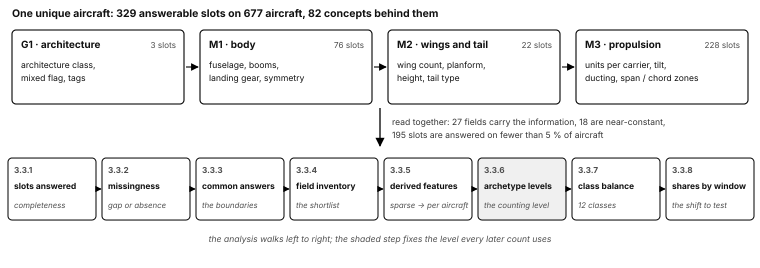

In [26]:
show('3.3')

*Note from the annotated index v1.1 (2026-09-09), kept verbatim — section numbers are the old index's:*

---
## 5. Design-space descriptives (→ Ch. 4 Variety and Diversity; 5.5 → Ch. 5)

*Note from the annotated index v1.1 (2026-09-09), kept verbatim — section numbers are the old index's:*

Opening figure: purpose of each subsection and the analysis it feeds.

#### 3.3.1 Slots answered per aircraft

The 329 columns of the four label cards G1 to M3 (the coded answers only: option ids, booleans and counts; free-text notes and the labelling-process flags are not slots) are slots, not concepts: 82 questions repeated over boom groups, wing panels and propulsor tiers. Sparsity is structural, a slot is blank when the part does not exist, so an aircraft answers a median of 49 slots and 195 slots are answered on fewer than 5 % of aircraft. 27 fields carry the information; 18 are near-constant.

,property of the label set,value
0,"Answerable slots (G1 to M3, coded columns; free text and process flags excluded)",329
1,Distinct concepts behind them (repeats collapsed),82
2,"Slots answered per aircraft, median",49
3,"Slots answered per aircraft, lower quartile",41
4,"Slots answered per aircraft, upper quartile",60
5,"Slots answered per aircraft, minimum",13
6,"Slots answered per aircraft, maximum",109
7,Slots answered on more than 90 % of aircraft,18
8,Slots answered on fewer than 5 % of aircraft,195
9,Fields with the same answer on 95% or more (answered on at least 100),18


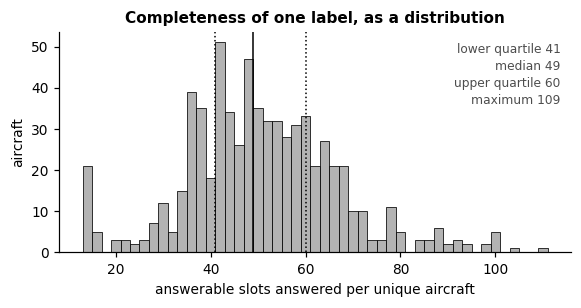

In [27]:
show('3.3.1')
display(a2.d2_label_set(ds, near_constant_min_answered=F.get('near_constant_min_answered', 100),
    near_constant_share=F.get('near_constant_share', 0.95),
    informative_min_answered=F.get('informative_min_answered', 300),
    informative_min_effk=F.get('informative_min_effective', 1.5)))
_ = figures.slots_histogram(a2.d2_slots_per_aircraft(ds))

*Note from the annotated index v1.1 (2026-09-09), kept verbatim — section numbers are the old index's:*

### 4.2 Slots answered per aircraft

- **Source**: D2.
- **Tables / figures**: median, quartiles, maximum; histogram.
- **Gives →** completeness of one label as a distribution, not a single number. Feeds: reliability paragraph.

#### 3.3.2 Missingness

A blank is a labelling gap only where the parent field says the part exists. On that test nearly every blank is design absence; the three real gaps are wing height, wing planform and tail type on winged aircraft. No aircraft is dropped for blanks, and landing gear "Unknown" means not drawn, never absent.

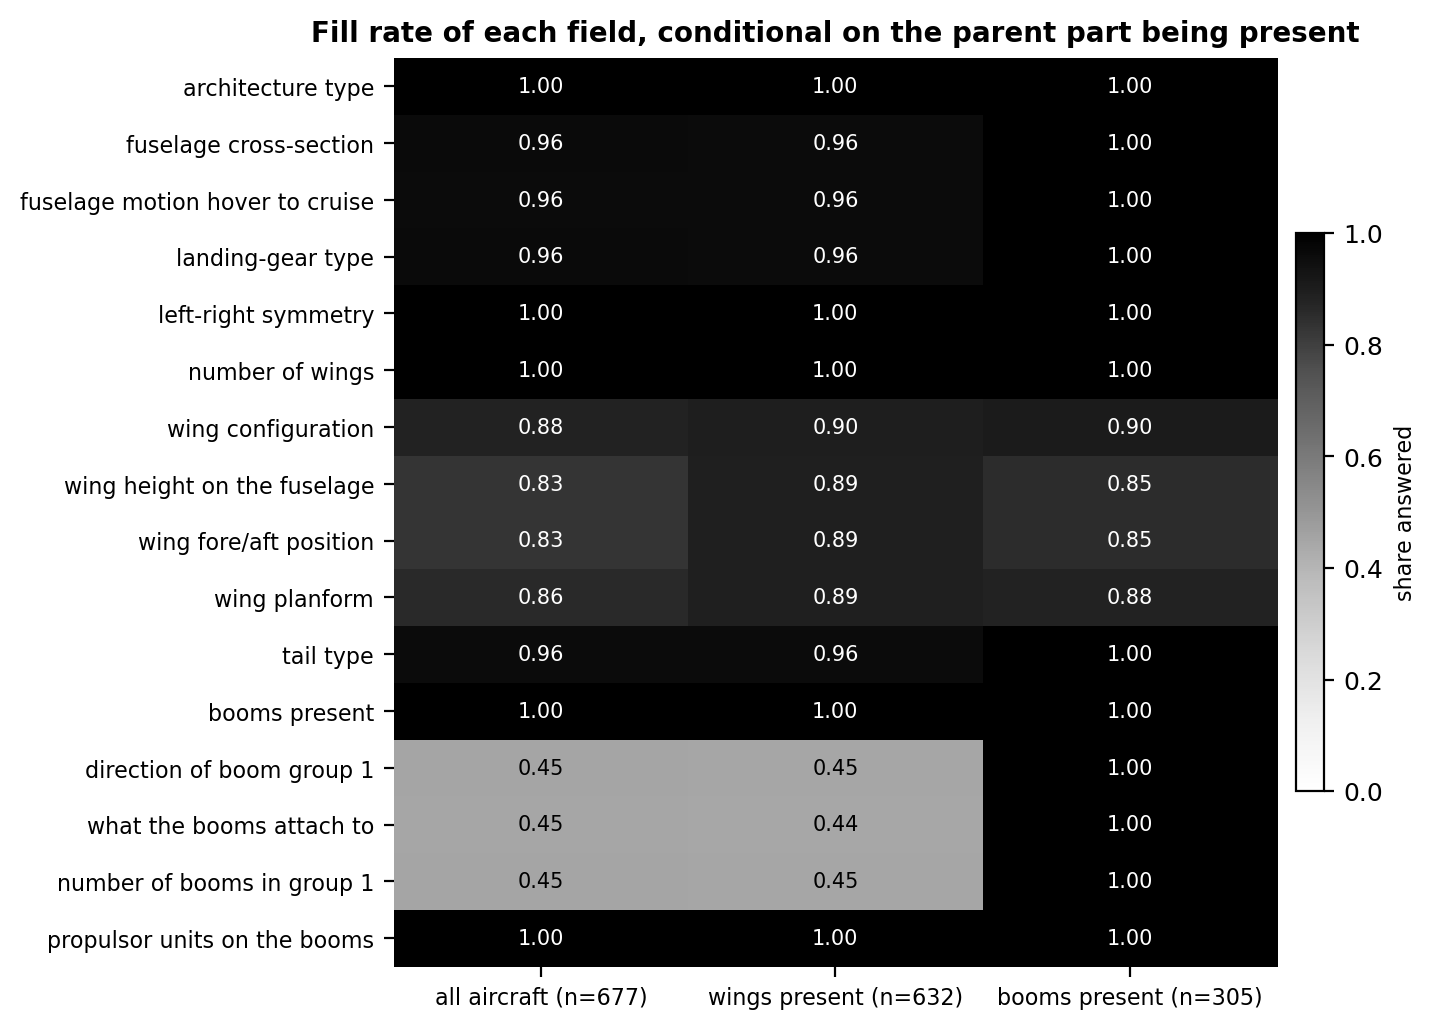

,check,affected,of,share
0,Booms present but boom direction blank,0,305,0.000
1,Architecture type blank,2,677,0.003
2,Wings present but wing height blank,69,632,0.109
3,Wings present but wing planform blank,69,632,0.109
4,Wings present but tail type blank,27,632,0.043
5,Fuselage cross-section blank,25,677,0.037


,flag,column,aircraft
0,Mixed architecture,notPureArch,32
1,Annotator unsure at G1,g1_humanUncertain,32
2,"Figure readability ""Impossible""",dinoUnderstanding,29
3,Annotator unsure at M2,m2_humanUncertain,6
4,Annotator unsure at T1,t1_humanUncertain,4
5,Annotator unsure at M1,m1_humanUncertain,2
6,Quick count override,g1_quickOverride,2


In [28]:
show('3.3.2')
display(a2.d4_missingness(ds))
a2.d6_weak_labels(ds)

*Note from the annotated index v1.1 (2026-09-09), kept verbatim — section numbers are the old index's:*

### 1.4 Missingness and weak labels: which aircraft enter the analysis

- **Source**: D4 (structural missingness), D6 (uncertainty flags), D3 note on gearArch = Unknown.
- **Tables / figures**: conditional-fill table; one heatmap of fill rate conditional on parent. Flag table. Output of this section: the list of unique aircraft that enter, with their sensitivity flags (the roster).
- **Gives →** a blank is a labelling gap only where the parent says the part exists; on that test nearly every blank is design absence, so no aircraft is dropped for blanks. The three real gaps (wing height, planform, tail) are fixed or declared "not visible". Landing gear Unknown means not drawn, never absent. The flagged rows stay in, marked, and every analysis is run with and without them. Feeds: 1.5 and 1.6 operate on this list; Ch. 4 quality reads the numbers back; Gower δ treatment in Ch. 5.

In [29]:
show('3.3.3')
display(a2.d3_selected_fields(ds))
a2.d2_near_constant_fields(ds, min_answered=F.get('near_constant_min_answered', 100), min_share=F.get('near_constant_share', 0.95))

#### 3.3.3 Most common answers, G1 to M3 labels

The table covers the aircraft-level labels G1 to M3 only. Which answers dominate says where the design space has boundaries: one wing, a fixed fuselage, standard wings, left-right symmetry. Near-constant fields are reported as findings and then excluded from distances.

,name,field,answered,answers,top_share,most common answers
0,number of wings,wCount,677,4,0.62,1 422 · 2 191 · 0 45 · 3 19
1,tail type,empType,649,13,0.29,Tailless (None) 190 · Conventional (Horizontal at base) 79 · V-Tail 69 · Single Vertic...
2,fuselage motion hover to cruise,fusKin,650,4,0.85,Fixed / Conventional 554 · Whole-Body Pitch 62 · Tail-sitter 21 · Variable Incidence 13
3,wing configuration,wingConf,596,5,0.87,Standard Wings 519 · Other 50 · Blended Wing Body 20 · Lifting Body 6
4,landing-gear type,gearArch,651,4,0.69,Unknown 448 · Wheeled Gear 104 · Skids / Fixed Skids 98 · Pads / Hull 1
5,left-right symmetry,latSym,677,2,0.96,True 647 · False 30


,name,field,card,answered,answers,top_share,effective_answers
0,,wing1_role,M2,652,1,1.00,1.00
1,,wing1_sym,M3,564,2,1.00,1.02
2,,emp_rmech,M3,100,1,1.00,1.00
3,,wing2_sym,M3,204,2,1.00,1.03
4,,emp_ntypes,M3,459,2,1.00,1.02
5,,wing2_rmech,M3,110,2,0.99,1.05
6,,boom2_circSym,M1,152,2,0.99,1.07
7,,empTilts,M2,677,2,0.98,1.09
8,,wing1_rmech,M3,307,3,0.98,1.11
9,,wing2_ntypes,M3,204,2,0.97,1.14


*Note from the annotated index v1.1 (2026-09-09), kept verbatim — section numbers are the old index's:*

### 5.1 Most common answers per field, and near-constant fields

- **Source**: D3 second table, D2 (near-constant fields), A.3 group 2.
- **Tables / figures**: field × answered × answers × top share × most common answers. Separate list of the near-constant fields.
- **Gives →** which answers dominate and which fields cannot separate designs. Near-constant fields are reported as findings about the boundaries of the design space, then excluded from distances. Feeds: field shortlist; Ch. 4 descriptive statements.

In [30]:
show('3.3.4')
a2.d2_informative_fields(ds, min_answered=F.get('informative_min_answered', 300), min_effk=F.get('informative_min_effective', 1.5))

#### 3.3.4 Field inventory

Fields answered on at least 300 aircraft, ranked by effective number of answers; tail type and architecture class spread widest. The cumulative columns say how much of a field its two and three most common answers already cover. This is the shortlist for the distances and the coupling analysis.

,name,field,card,answered,answers,top_share,effective_answers,top2_cumulative,top3_cumulative
0,tail type,empType,M2,649,13,0.29,8.5,0.41,0.52
1,architecture type,topType,G1,675,12,0.27,7.3,0.51,0.68
2,propulsor units on the booms,boom_count,M3,676,18,0.59,4.4,0.73,0.81
3,,wing1_count,M3,564,22,0.40,4.4,0.78,0.88
4,propulsors along the wing span,wing1_zoneSpan,M3,333,5,0.44,3.8,0.72,0.86
5,,fuselage_count,M3,625,17,0.62,3.5,0.81,0.91
6,direction of boom group 1,boom1_orient,M1,305,5,0.61,3.2,0.79,0.90
7,wing height on the fuselage,wing1_posV,M2,563,4,0.60,3.0,0.81,0.92
8,fuselage cross-section,fusShape,M1,652,5,0.63,2.9,0.84,0.92
9,wing planform,wing1_plan,M2,583,5,0.62,2.7,0.90,0.96


*Note from the annotated index v1.1 (2026-09-09), kept verbatim — section numbers are the old index's:*

### 5.2 Field inventory: effective number of answers, top share, cumulative

- **Source**: D2 ranked table (`phase1_field_inventory.csv`).
- **Tables / figures**: ranked table of the informative fields with card, answered, answers, top share, effective number, and the cumulative share of the top-2 and top-3 answers.
- **Gives →** which fields carry information; the shortlist for Gower, Cramér's V and archetypes chosen from evidence. Feeds: Ch. 4 Variety; Ch. 5 methods (Gower field list, weights).

*Note from the annotated index v1.1 (2026-09-09), kept verbatim — section numbers are the old index's:*

*Assumption for "cumulative" in the index:* the cumulative share of the two and three most
common answers (`top2_cumulative`, `top3_cumulative`); say so if another reading was meant.

In [31]:
show('3.3.5')
display(a3.derived_layer_summary(ds))
a3.derived_layer(ds).head()

#### 3.3.5 Derived per-aircraft features

The sparse boom and tier slots become variables every aircraft has: total propulsor units, any tilting unit, mixed fixed and tilting units, any ducted unit, all units ducted.

,derived variable,value
0,"Total propulsor units, median",5
1,"Total propulsor units, quartiles",3-8
2,Aircraft with more than 8 propulsor units,123
3,Aircraft with any tilting unit,246
4,Aircraft mixing fixed and tilting units,96
5,Aircraft with any ducted unit,235
6,Aircraft whose units are all ducted,137


,patent_id,variant,propulsor_units,any_tilting_unit,mixes_fixed_and_tilting,any_ducted_unit,all_units_ducted,thrust_axis_mix,propulsor_carriers,units_on_the_wing_span,units_on_the_wing_chord
0,US2021331794A1,1,4,True,False,False,False,True,2,Wingtip,LE
1,US2023056709A1,1,6,False,False,False,False,False,1,NaN,NaN
2,US2023056709A1,2,4,False,False,False,False,False,1,NaN,NaN
3,US2018244367A1,1,4,False,False,False,False,False,1,NaN,NaN
4,US2018265189A1,1,3,False,False,False,False,False,1,NaN,NaN


*Note from the annotated index v1.1 (2026-09-09), kept verbatim — section numbers are the old index's:*

### 5.2b Derived per-aircraft features (D2b)

- **Source**: A.3 group 1 (addition 1).
- **Tables / figures**: total propulsor units, any tilting, mixed fixed and tilting, any ducted, all ducted, thrust-axis mix, units per carrier. One table.
- **Gives →** the sparse boom and tier slots as variables every aircraft has. Feeds: Gower, Cramér's V, MCA.

#### 3.3.6 Archetype cardinality

An archetype is the string formed by joining the chosen fields; *distinct archetypes* counts those strings, and the *effective number* is the exponential of the Shannon entropy of their shares. Two columns decide the level. *Singletons* counts archetypes holding exactly one aircraft; above roughly five per cent of the corpus (34 aircraft) the level has stopped naming kinds of aircraft and started naming individual ones. The effective number against the distinct count is the same test from the other side: close together means every archetype is about equally rare, well apart means a few archetypes carry most of the aircraft, which is what a design space looks like. The finest level that holds both is taken. On the current numbers A0 is safe but too coarse to show movement, A1 holds at 15 singletons in 675, and A2 fails on both counts. A1b bins the number of booms because the raw count has 11 answers and reads as a measurement rather than a design decision; A1t tests whether the same resolution is reached through tilt, the feature the architecture classes actually turn on (246 aircraft tilt a unit).

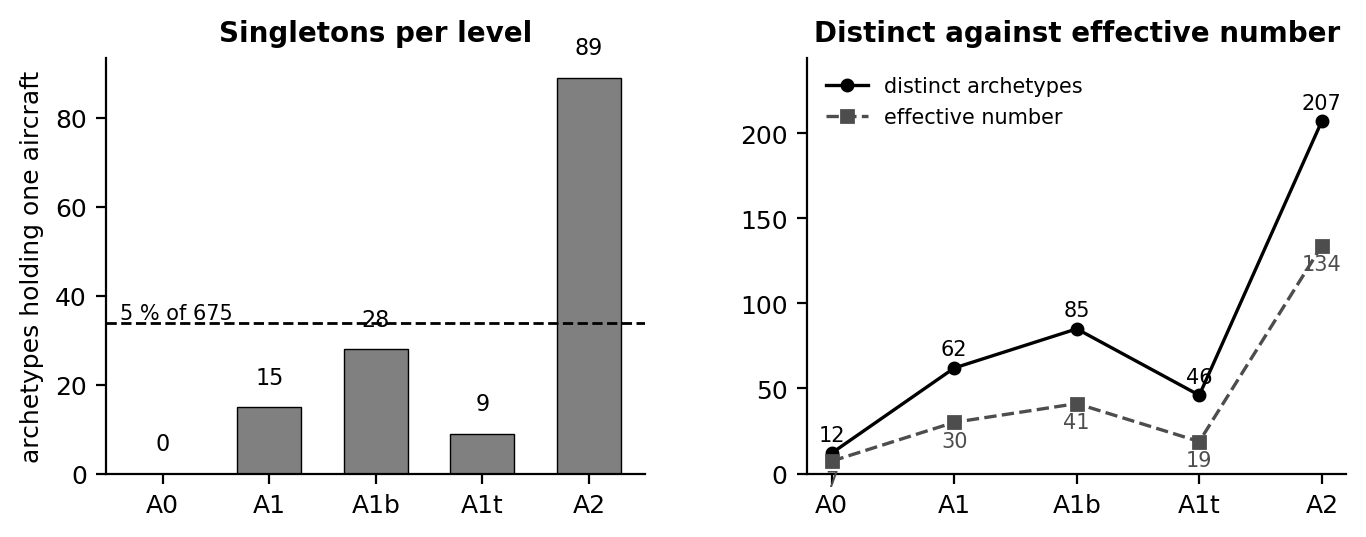

,level,fields combined,aircraft,distinct archetypes,singletons,singleton share,effective number
0,A0,architecture class,675,12,0,0.000,7.3
1,A1,"+ number of wings, booms present",675,62,15,0.022,30.1
2,A1b,"+ number of wings, booms binned none / 1-2 / 3 / 4 or more",675,85,28,0.041,41.1
3,A1t,"+ number of wings, any tilting unit",675,46,9,0.013,18.8
4,A2,"+ number of wings, booms present, tail type",675,207,89,0.132,133.8


In [32]:
show('3.3.6')
a2.d5_archetype_cardinality(ds)

*Note from the annotated index v1.1 (2026-09-09), kept verbatim — section numbers are the old index's:*

### 5.3 Archetype cardinality

- **Source**: D5.
- **Tables / figures**: level × fields × distinct × singletons × effective number.
- **Gives →** how fine a design species can be before every patent is its own kind; A1 (three fields) is the counting archetype, finer levels enter only through distances. Feeds: G.4 #3; Ch. 5 Hill numbers.

#### 3.3.7 Architecture class balance

12 classes, the largest (Lift + Cruise) at 0.27: balanced enough for windows of about 40 aircraft. The 4 classes below twelve aircraft are the candidates for merging or dropping in the frozen-model chapter.

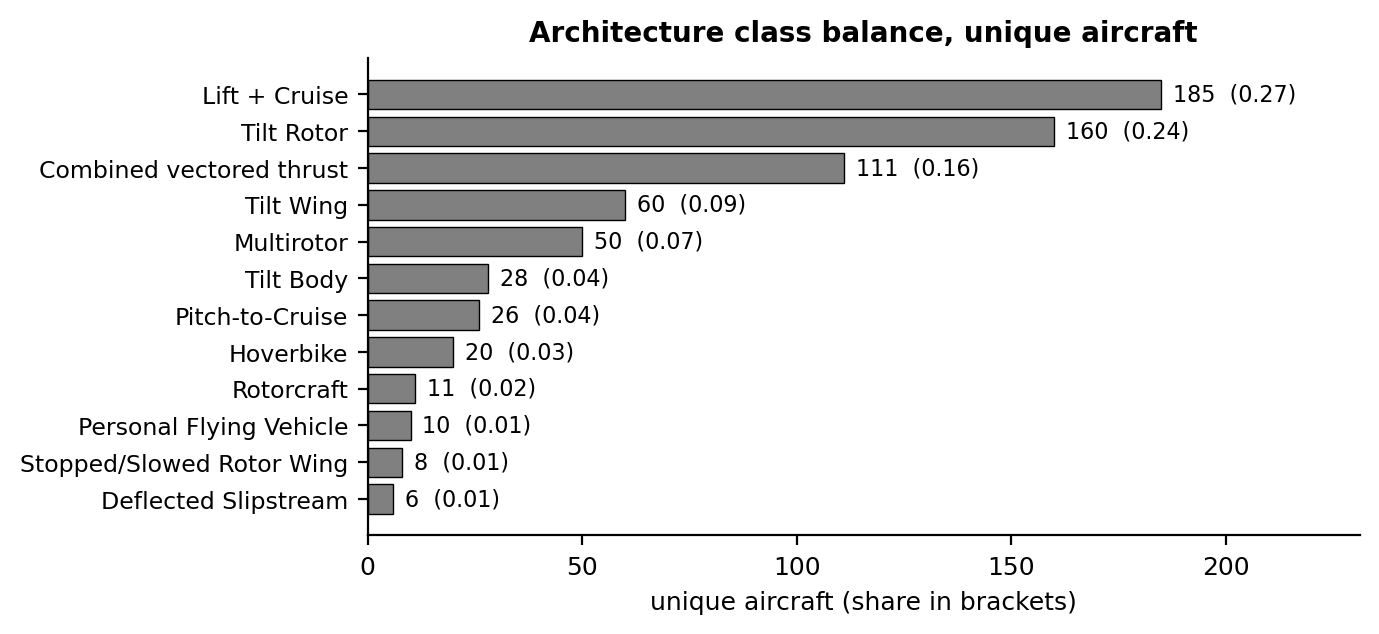

,name,value,count,share
0,Lift + Cruise,SLC,185,0.27
1,Tilt Rotor,TR,160,0.24
2,Combined vectored thrust,CVT,111,0.16
3,Tilt Wing,TW,60,0.09
4,Multirotor,MR,50,0.07
5,Tilt Body,TB,28,0.04
6,Pitch-to-Cruise,PTC,26,0.04
7,Hoverbike,HB,20,0.03
8,Rotorcraft,RC,11,0.02
9,Personal Flying Vehicle,PFV,10,0.01


In [33]:
show('3.3.7')
a2.d3_architecture_balance(ds)

*Note from the annotated index v1.1 (2026-09-09), kept verbatim — section numbers are the old index's:*

### 5.4 Architecture class balance

- **Source**: D3 first table.
- **Tables / figures**: architecture type × aircraft × share; bar chart.
- **Gives →** the class variable is balanced for twelve classes, so classes are large enough for windows of ~40. Feeds: Ch. 4 Variety; Ch. 6 class list for the frozen model; merging or dropping of small classes.

#### 3.3.8 Class shares per window

A first look at a shift from tilt rotor to lift plus cruise, and no class above 0.33 in any window, so raw shares show no dominant design. This is the pattern the evolution chapter tests, not assumes.

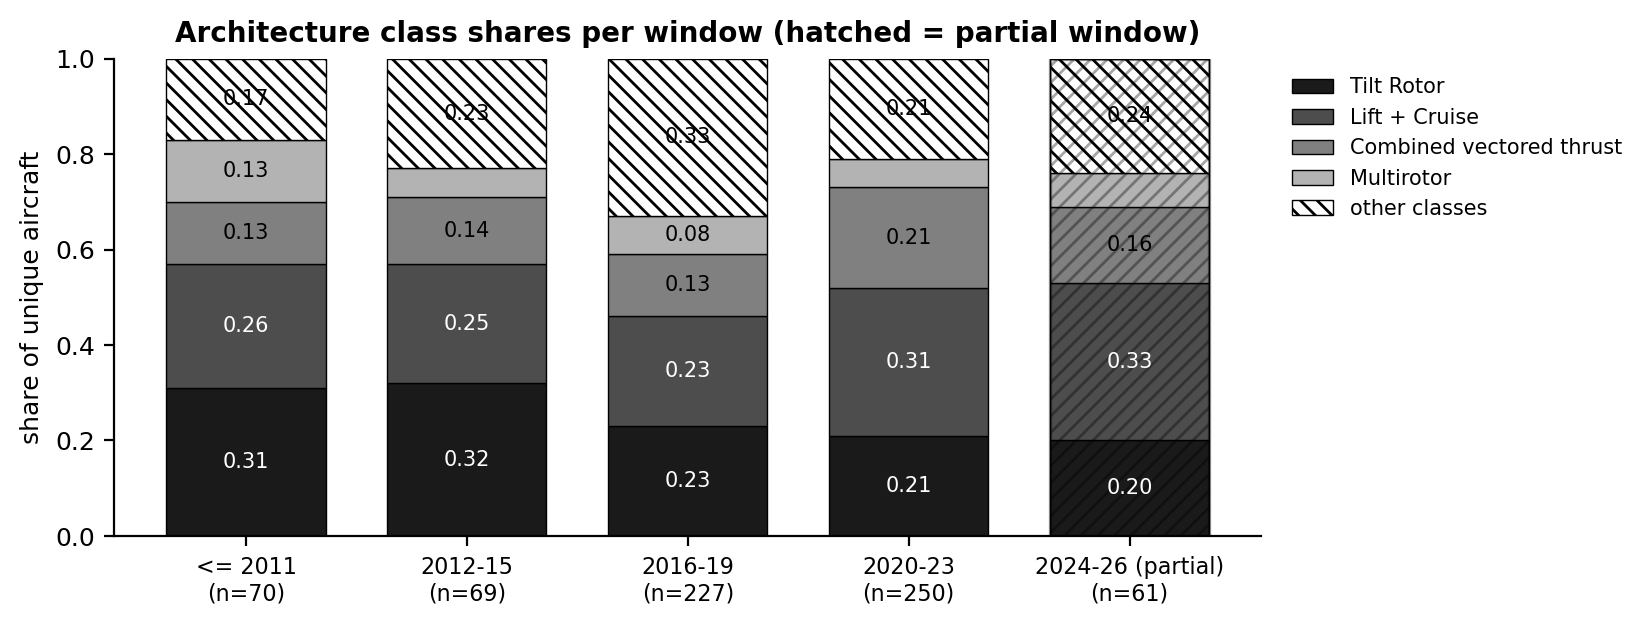

largest share of any class in any window: 0.33


,window,unique aircraft,Tilt Rotor,Lift + Cruise,Combined vectored thrust,Multirotor
0,<= 2011,70,0.31,0.26,0.13,0.13
1,2012-15,69,0.32,0.25,0.14,0.06
2,2016-19,227,0.23,0.23,0.13,0.08
3,2020-23,250,0.21,0.31,0.21,0.06
4,2024-26 (partial),61,0.20,0.33,0.16,0.07


In [34]:
show('3.3.8')
windows = a2.d9_architecture_by_window(ds)
print('largest share of any class in any window:', round(windows.attrs['max_share_any_class_any_window'], 2))
windows

*Note from the annotated index v1.1 (2026-09-09), kept verbatim — section numbers are the old index's:*

### 5.5 Class shares per window

- **Source**: D9 window table.
- **Tables / figures**: window × variants × share of TR / SLC / CVT / MR; stacked-area figure with the partial window hatched.
- **Gives →** a first look at a shift from tilt rotor to lift plus cruise, and no class above about a third in any window, so raw shares show no dominant design. This is the pattern Ch. 5 tests, not assumes. Feeds: Ch. 5 window definition and hypotheses.

---
## Chapter 4 — Data Quality and Validity

In [35]:
show('4')

### Chapter 4 — Data Quality and Validity

For now this chapter compares what is already known publicly against what the methodology recovered. In the thesis it is done differently.

*Note from the annotated index v1.1 (2026-09-09), kept verbatim — section numbers are the old index's:*

---
## 4. Label quality (→ Ch. 4 Quality of data and methods of certifying it)

*Note from the annotated index v1.1 (2026-09-09), kept verbatim — section numbers are the old index's:*

### 4.1 Missingness and uncertainty, read back

- **Source**: sections 1.4 (D4, D6). No new table.
- **Tables / figures**: none; one paragraph pointing to 1.4.
- **Gives →** the quality verdict on the labels that entered: which fields carry declared gaps, how many rows are flagged, and the size of the sensitivity set. Feeds: reliability paragraph.

*Note from the annotated index v1.1 (2026-09-09), kept verbatim — section numbers are the old index's:*

No new table: the D4 conditional-fill table, the D6 flag table and the roster summary of 1.4 are
the quality verdict on the labels that entered.

*Note from the annotated index v1.1 (2026-09-09), kept verbatim — section numbers are the old index's:*

### 4.3 Consistency rules

- **Source**: D12 (02a rule-violation counts before and after correction). Partial: only the batches 02a has been run on.
- **Tables / figures**: one table of rule applications and skips per batch.
- **Gives →** internal coherence of the labelling; reliability evidence that does not need a second annotator. Feeds: reliability paragraph.

*Note from the annotated index v1.1 (2026-09-09), kept verbatim — section numbers are the old index's:*

Partial until 02a has been run on every batch: the table reads whatever `rule_decisions_*.json`
files the configured glob finds.

In [36]:
show('4.1')
a2.d13_flagship_check(ds).head(20)

### 4.1 Flagship check

Where a company's product is public, the top label agrees with it; the disagreements are alternative embodiments filed by the same firm, which is itself a finding. 56 companies with two or more aircraft are checked; the first eight are shown.

An intra-rater re-label, kappa per field on 60 to 100 patents at least four weeks after the last labelling, is later work and not a result of this document.

,company,aircraft,labels,distinct types,public products,public types differ,top label matches a public type
0,Bell / Textron,64,Tilt Rotor 28 · Combined vectored thrust 17 · Tilt Body 8 · Tilt Wing 8 · Lift + Cruise 1,7,APT (TB) · Nexus (TR),True,True
1,Airbus,24,Lift + Cruise 16 · Multirotor 4 · Pitch-to-Cruise 3 · Combined vectored thrust 1,4,CityAirbus (MR) · CityAirbus NextGen (SLC),True,True
2,Kitty Hawk,11,Tilt Wing 3 · Multirotor 3 · Lift + Cruise 2 · Tilt Rotor 2 · Stopped/Slowed Rotor Wing 1,5,Flyer (MR) · Heaviside (TR),True,False
3,Leonardo,10,Combined vectored thrust 6 · Tilt Rotor 4,2,,False,None
4,Honda,9,Lift + Cruise 6 · Multirotor 1 · Hoverbike 1 · Personal Flying Vehicle 1,4,Honda eVTOL (SLC),False,True
5,Shenfeng Aviation,9,Lift + Cruise 4 · Combined vectored thrust 2 · Pitch-to-Cruise 1,3,,False,None
6,Joby Aviation,8,Combined vectored thrust 3 · Tilt Rotor 2 · Lift + Cruise 2 · Tilt Wing 1,4,S4 (TR),False,False
7,Aurora Flight Sciences,8,Lift + Cruise 5 · Tilt Wing 2 · Combined vectored thrust 1,3,Passenger Air Vehicle (SLC),False,True
8,Porsche,8,Lift + Cruise 3 · Combined vectored thrust 2 · Pitch-to-Cruise 2 · Rotorcraft 1,4,,False,None
9,Boeing,7,Lift + Cruise 2 · Combined vectored thrust 2 · Tilt Rotor 1 · Multirotor 1 · Personal ...,5,Passenger Air Vehicle (SLC),False,True


*Note from the annotated index v1.1 (2026-09-09), kept verbatim — section numbers are the old index's:*

### 4.4 Flagship check

- **Source**: D13.
- **Tables / figures**: company × labels × public product × verdict.
- **Gives →** the labels agree with what the world knows where the answer is public; the disagreements are alternative embodiments, which is itself a sentence in the thesis. Feeds: external validation in Ch. 4; a short re-read list. Open: whether the intra-rater re-label (κ per field, 60–100 patents, 4 weeks after last labelling) enters as 4.5 or is a stated scope decision.

*Note from the annotated index v1.1 (2026-09-09), kept verbatim — section numbers are the old index's:*

---
## Additions worth considering

*Note from the annotated index v1.1 (2026-09-09), kept verbatim — section numbers are the old index's:*

### A.6 Named-aircraft state (A.5)

- **Source**: A.5 (addition 6).
- **Tables / figures**: name proposals by source; what is reviewed and where.
- **Gives →** proposals exist but none is verified; company-attributed names are statements about the assignee, not the drawing. One short table if the named-aircraft stratum stays in RQ3; otherwise a sentence in 3.2.

*Note from the annotated index v1.1 (2026-09-09), kept verbatim — section numbers are the old index's:*

### Not in the preliminary analysis (by design)

Image-vs-text agreement (κ 0.61), Hill numbers, Rao's Q, MCA, permutation tests, kNN communities. These are results of Ch. 4–7, and the preliminary analysis only has to hand them a fixed dataset, a field shortlist, an archetype level, a window definition and a sensitivity-flag list.

---
## Chapter 5 — Method for the Design Space and Evolution Analysis

### Chapter 5 — Method for the Design Space and Evolution Analysis

The class shares of section 3.3.8 move in one direction across 27 years, from tilt rotor toward lift plus cruise, and at the same time no class holds more than about a third of any window. Read on their own those two observations point opposite ways, the first toward a sector settling on an answer and the second toward one still exploring. Separating them is the work of the evolution analysis. This chapter specifies that analysis, and names the result in the preceding chapters that makes each step available.

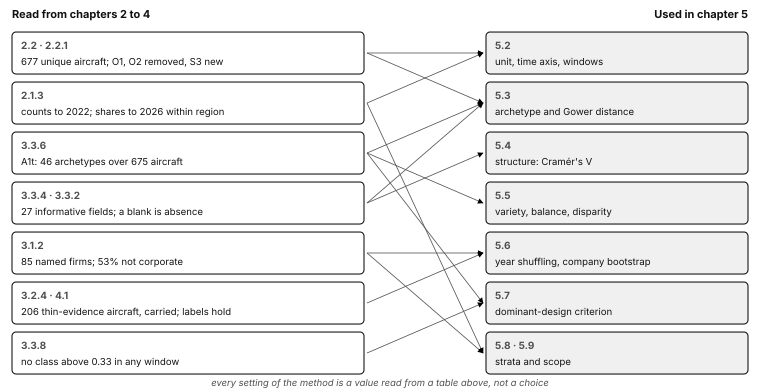

In [37]:
show('5')

In [38]:
show('5.1')
ch5.settings_table(N)

### 5.1 What this document settles

An evolution study makes a handful of choices before it computes anything. Which unit is counted. Which years can be compared. How fine a design species is. Which fields carry information. What a blank means. Which aircraft rest on thin evidence. Taken in isolation each is a matter of taste. Taken from the tables of chapters 2 to 4, each is a matter of record.

,choice,fixed in,value
0,unit counted,2.2,"the unique aircraft, 677, and not the patent"
1,years compared,2.1.3,"to 2022 for counts; to 2026 for shares, within region"
2,one independent design,"2.2.1, 3.1.2","the aircraft, O1 and O2 removed, S3 counted as new"
3,design species,3.3.6,"A1t: architecture class by wing count by any tilting unit, 46 archetypes"
4,informative fields,3.3.4,"27, with the 18 near-constant ones held out of the distance"
5,a blank,3.3.2,"absence, dropped from a comparison instead of counted as difference"
6,thin evidence,3.2.4,"206 aircraft, marked and carried, never removed"
7,labels hold,4.1,they agree with the public product wherever the product is public


In [39]:
show('5.2')
a2.d9_architecture_by_window(ds)[['window', 'unique aircraft']]

### 5.2 Unit, time axis and windows

The unit is the primary representative unique aircraft. Each aircraft enters once. Metadata belonging to a filing and not to a design, such as citations and legal status, is counted at the patent.

The time axis is the priority year, the date closest to the design decision. The application and publication years lag it by amounts that differ by office (2.1.3).

Windows are 2011 and earlier, 2012 to 2015, 2016 to 2019, 2020 to 2023, and 2024 to 2026, holding 70, 69, 227, 250 and 61 aircraft. The last is partial and is drawn hatched. Counts stop at 2022 and shares run to 2026 within region, under the rule of 2.1.3.

,window,unique aircraft
0,<= 2011,70
1,2012-15,69
2,2016-19,227
3,2020-23,250
4,2024-26 (partial),61


In [40]:
show('5.3')
a2.d5_archetype_cardinality(ds).set_index('level').loc[['A1', 'A1b', 'A1t']]

### 5.3 The archetype and the distance

The same aircraft is represented two ways, because the measures need different things. One representation is discrete, so kinds can be counted. The other is continuous, so degrees of difference can be measured without naming kinds at all.

**The archetype.** An archetype is a name for a kind of design, formed by joining a few label fields into one string. A1t, defined in 3.3.6, joins architecture class, number of wings, and whether any propulsor tilts. It gives 46 archetypes over 675 aircraft. A1 and A1b are computed alongside as robustness, and every curve below is drawn at all three.

**The distance.** Gower's coefficient measures how different two aircraft are across the mixed categorical and count fields of the shortlist (Gower, 1971). For aircraft *i* and *j*,

```
d(i,j) = Σ w δ (1 − s)  /  Σ w δ
```

over fields *k*, where *s* is 1 when the two aircraft share a category and 0 when they do not, and *δ* is 1 only when both aircraft carry a value for that field. The *δ* term is what implements 3.3.2. A boom field does not exist for a wingless multirotor, so it leaves that pair's average instead of registering as a difference between them.

The weights *w* decide how much each field contributes, and the question they answer is concrete. The codebook spends 228 slots on propulsion and 3 on architecture class. That ratio records how much detail the labelling tool collects, and not how much each subsystem matters to a design. Weighting every field equally would carry that ratio into the measurement, and two aircraft would come out similar mainly because their propulsor slots match. The weights are therefore set by subsystem: each of architecture, wings, empennage, fuselage, booms and propulsion receives one unit of weight, divided among its own fields. A subsystem then counts once whatever number of columns the codebook spends on it.

Uniform weighting is computed as well, and reported as a robustness check. When the two produce the same shape, the finding is about the corpus. When they disagree, the finding is about the weighting, and the chapter says which. A third scheme, weighting each field by how strongly it constrains the others, was considered and dropped: the weights would come from an analysis of the same labels the distance is afterwards used to analyse.

The matrix is 677 by 677 and is computed once. Every measure below reads from it.

,fields combined,aircraft,distinct archetypes,singletons,singleton share,effective number
level,,,,,,
A1,"+ number of wings, booms present",675,62,15,0.022,30.1
A1b,"+ number of wings, booms binned none / 1-2 / 3 / 4 or more",675,85,28,0.041,41.1
A1t,"+ number of wings, any tilting unit",675,46,9,0.013,18.8


In [41]:
show('5.4')

### 5.4 Structure of the design space

For each pair of shortlist fields, the strength of association is measured by Cramér's V over their contingency table, computed only on aircraft to which both fields apply. Cramér's V runs from 0 to 1 and states how far knowing one field's answer tells you the other's. The output is a fields by fields heatmap, and it answers which design decisions travel together. The row sums rank the fields by how much each constrains the rest. A field that constrains many others is core to the design, and one that constrains none is peripheral.

Strongly associated fields are not double-counted in the distance, because two fields carrying the same information twice would weight that information twice.

In [42]:
show('5.5')

### 5.5 The three diversity measures

No single number expresses how diverse a technology is, so variety, balance and disparity are reported separately (Stirling, 2007). The three answer different questions about the same window, and they can move independently.

Within a window, *p* is the share of aircraft belonging to each archetype, and the shares sum to one.

**Variety and balance.** The Hill numbers are a family of three counts that differ in how much weight they give to rare archetypes (Hill, 1973).

```
⁰D = the number of archetypes present
¹D = exp(−Σ p ln p)          the exponential of Shannon entropy
²D = 1 / Σ p²                 the inverse Simpson index
```

⁰D counts kinds and ignores how common each one is, so a single unusual design raises it as much as a mainstream one. ¹D and ²D rescale instead. Each states how many equally common archetypes would produce the spread actually observed, which is why both are read as a number of designs in play rather than a number of designs present. A window holding twelve archetypes where three quarters of its aircraft sit in two of them behaves like about three, and the distance between twelve and three is the message. ²D discounts rare archetypes more sharply than ¹D, so ⁰D ≥ ¹D ≥ ²D always, with equality only when every archetype is equally common.

⁰D is comparable across windows only at equal sample size, because the windows differ by a factor of four and a larger window finds more kinds for that reason alone. Forty aircraft are drawn without replacement from each window, the count is taken, and the draw is repeated a thousand times. The mean and the fifth to ninety-fifth percentile band are reported. This is rarefaction, and it is mandatory here and not optional: the raw counts rise and fall with window size in a way that has nothing to do with the design space.

**Disparity.** Rao's quadratic entropy is the expected distance between two aircraft drawn at random from the window (Rao, 1982). Read plainly, it answers how different two eVTOL concepts from that period would be if they were picked blind.

```
Q = Σᵢ Σⱼ pᵢ pⱼ d(i,j)
```

Q needs no archetype, which makes it the independent check on the other two, and it carries the fine labels the archetype leaves behind. It can move while the Hill numbers are still, and the reverse.

The three read as a set. Balance falling with disparity holding means the field is concentrating on fewer designs that nonetheless remain far apart. Both falling is convergence.

**Turnover.** Per window, the archetypes appearing for the first time, those last seen, and the Jaccard overlap with the previous window, which is the share of archetypes the two windows hold in common. It shows branches opening and closing directly.

In [43]:
show('5.6')
a2.d8_split_firms(ds, 'Bell / Textron')

### 5.6 Significance and uncertainty

Any curve moves a little even when design and date are unrelated, because each window holds a different number of aircraft and a different draw of designs. Two guards separate real movement from that noise, and chapter 3 licenses both.

**Year shuffling.** The claim under test is that which architecture an aircraft has depends on when it was filed. The test builds corpora in which that dependence is removed and nothing else is changed. Every aircraft keeps its labels exactly as they are, and only the priority years are dealt out again at random. The same aircraft and the same window sizes survive, and design and date are now unrelated by construction. The measure is recomputed there, a thousand times, and the spread of those thousand values is how much movement the window structure produces on its own. Drawn as a shaded band behind the real curve, it shows at a glance how much of the curve is signal. A fall matched by a third of the shuffles is evidence of nothing. A fall matched by twelve of them is a finding.

**Company bootstrap.** Confidence bands are built by resampling companies and not patents. A bootstrap builds an error bar by drawing a corpus of the same size at random with replacement, recomputing the measure, and repeating. Resampling companies is what makes the band answer the right question, which is how much the curve would move if a different set of firms had happened to file. Bell and Textron file under 5 assignee strings and stand behind 35% of the tilt-rotor aircraft of named companies (28 of 79, 3.1.2). One firm filing thirty patents on one aircraft is one design decision, and a band built on patents would treat it as thirty and report the field as more certain than it is. The year shuffling is run within company for the same reason.

Effect sizes are reported with their bands. The permutation probability is the guard and not the result.

,assignee string,patents
0,BELL HELICOPTER TEXTRON INC,25
1,BELL TEXTRON INC,17
2,TEXTRON INNOVATIONS INC,8
3,AAI CORP,1
4,TEXTRON SYSTEM CORP,1


In [44]:
show('5.7')

### 5.7 The dominant-design criterion, fixed in advance

A dominant design is the configuration an industry settles on after a period of competing alternatives, and its arrival changes what firms compete over. The automobile industry is the standard case (Abernathy and Utterback, 1978). Steam, electric and petrol propulsion competed for three decades, the front-engine petrol layout became the shape every manufacturer built, and competition moved from the arrangement of the vehicle to its cost and refinement. Whether the eVTOL sector has reached that point is the question this analysis exists to answer.

The criterion is written here, before any curve is drawn. The reason is that a measure of convergence can be read as supporting almost any account once the curves are in front of the reader, and a criterion stated afterwards carries no weight. A dominant design is recorded when all three conditions hold in the same window, and the window is complete.

1. One A1t archetype holds more than half the aircraft, in two consecutive windows. More than half means most of the sector is proposing the same design. Two windows means the share is not a single unusual period.
2. ²D falls below the permutation band of the earliest windows. The window then holds fewer designs in play than the shuffled corpora produce by chance, so the concentration is in the corpus and not in the window structure. A fixed cutoff was considered and set aside: a threshold such as two designs in play cannot be justified against 2.5, while the band is computed from this corpus and moves with it.
3. Q falls below the level of the earliest windows by more than the permutation band. The aircraft have become similar to one another, and not only concentrated in one name.

The three conditions are deliberately different in kind. The first is about counts, the second about balance, the third about form. A sector can satisfy one and not the others, and each of those cases is a different state of the technology.

The corpus already indicates the first condition will not be met. No architecture class exceeds 0.33 of any window in table 3.3.8, and A1t subdivides those classes further, so the largest archetype share is smaller still. That result stands on its own: 27 years of eVTOL patents, and the sector has not converged on a single architecture.

The measurement that matters is therefore the second reading, and it is specified with the same care. ²D can fall while Q holds. Fewer designs would then be in play, while the designs that remain stay far apart in form. That is a field narrowing without having chosen a shape, and it is a more precise claim about the state of eVTOL development than a plain absence of convergence. Both readings are fixed before either is observed, and whichever the corpus supports is reported with the same weight.

In [45]:
show('5.8')

### 5.8 Strata

53% of the corpus is not corporate. 182 primary patents belong to individual inventors and 127 to filers that resolve to no known company, against 276 from 85 named firms (3.1.2). Assignee type is therefore a stratum the corpus can support, and the ferment-to-dominance account makes a prediction about it: individuals and universities are expected to keep exploring after companies have converged. Every curve of 5.5 is repeated by assignee type.

Region is reported next to every curve and is never used as a filter, for the reason given in 3.1.1. It becomes a split and not an annotation in the 2024–2026 window, under the rule of 2.1.3.

In [46]:
show('5.9')

### 5.9 Scope

Two boundaries are set by decision.

The 2024–2026 window carries shares and not counts, and within region and not pooled.

The frozen-model comparison receives the 12 architecture classes of 3.3.7 and the whole-aircraft figures of 3.2.2. What a frozen vision model recovers from them is the subject of its own chapter, and no result in this chapter depends on it. Every number above is computed from the labels alone, so no measurement of the design space can be disturbed by a model's errors.

In [47]:
show('5.10')
ch5.judgement_table(N)

### 5.10 Choices that rest on the author's judgement

Most of the settings in table 5.1 are read from a measurement in chapters 2 to 4. Three are not. Each of the three is argued in the section that makes it, and each has a defensible alternative, so they are collected here with what would change if the alternative were taken. They are open until the analysis is run and are recorded so that a reader can disagree with a specific sentence and not with the document as a whole.

The first two are the substantive ones, because they change what is computed. The third changes only what the result is compared against.

,choice,taken here,the alternative,what changes if it flips
0,archetype level (3.3.6),"A1t, architecture class by wing count by any tilting unit, because booms are structure...","A1 or A1b, both of which keep the singleton count inside the same regime","the design-species row of table 5.1, the archetype paragraph of 5.3, condition 1 of 5...."
1,field weights in the distance (5.3),"one unit per subsystem, because 228 propulsion slots against 3 architecture slots reco...","uniform weights, the conventional default for Gower's coefficient",which of the two weightings is the main result and which is the robustness run; the cu...
2,the balance condition (5.7),²D falls outside the permutation band of the earliest windows,"a fixed cutoff such as two designs in play, as used in parts of the dominant-design li...","the wording of condition 2, and whether the convergence verdict rests on a constant or..."


---
## References

In [48]:
show('references')

## References

- Abernathy, W. J. and Utterback, J. M. (1978), "Patterns of industrial innovation", *Technology Review* 80(7), 40–47.
- Gower, J. C. (1971), "A general coefficient of similarity and some of its properties", *Biometrics* 27(4), 857–871.
- Hill, M. O. (1973), "Diversity and evenness: a unifying notation and its consequences", *Ecology* 54(2), 427–432.
- Rao, C. R. (1982), "Diversity and dissimilarity coefficients: a unified approach", *Theoretical Population Biology* 21(1), 24–43.
- Stirling, A. (2007), "A general framework for analysing diversity in science, technology and society", *Journal of the Royal Society Interface* 4(15), 707–719.

*Note from the annotated index v1.1 (2026-09-09), kept verbatim — section numbers are the old index's:*

---
## Export — tables, figures, the roster and the draft document

`outputs/preliminary_analysis/` gets every table as CSV and markdown (`tables/`), every figure as
PNG (`figs/`), and `PRELIMINARY_ANALYSIS.md`: the index text with the live tables and figures in
place. Edit the prose there; never the numbers. Render with
`python3 scripts/build_styled_md_pdf.py <md> <pdf>` from the repo root.

---
## Export — tables, figures, the document and its PDF

`outputs/preliminary_analysis/` gets every table as CSV and markdown (`tables/`, including the
codebook-rule counts and the framework appendix tables that the document does not print), every
figure (`figures/`, PNG charts and the three SVG schemes), `PRELIMINARY_ANALYSIS.md` and its PDF.
Edit the prose in `index.py`; never the numbers. The PDF must stay at ten pages or fewer.

In [49]:
TABLES = export.build_all(ds, F)
written = export.write_all(TABLES, OUT)
doc = report.write_markdown(ds, TABLES, FIGS, OUT, values=N, partial_window_start=PARTIAL)
print(f'{len(written)} tables, {len(FIGS)} figures -> {OUT}')
print('document:', doc.name, f'{doc.stat().st_size / 1024:.0f} KB')

/home/vasco/Vasco Workspace/Tese_Vasco_Lnx/eVTOL-Visual-Evaluation/labeling_evaluation/src/dataset_facts/numbers.py:203: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  n["flagship_match"] = int(pub["top label matches a public type"].fillna(False).astype(bool).sum())


81 tables, 12 figures -> /mnt/storage_11tb/Drive_files_to_syncronize/3 - Images DataSets & Labelling Outputs/1639_LABELLED/1_labelling_analysis/preliminary_analysis
document: PRELIMINARY_ANALYSIS.md 57 KB


In [50]:
import subprocess
pdf = doc.with_suffix('.pdf')
subprocess.run([sys.executable, str(ROOT.parent / 'scripts' / 'build_styled_md_pdf.py'), str(doc), str(pdf), '--compact'], check=True)
pages = subprocess.run(['pdfinfo', str(pdf)], capture_output=True, text=True).stdout
print(pdf.name, [l for l in pages.splitlines() if l.startswith('Pages')])

/mnt/storage_11tb/Drive_files_to_syncronize/3 - Images DataSets & Labelling Outputs/1639_LABELLED/1_labelling_analysis/preliminary_analysis/PRELIMINARY_ANALYSIS.pdf 1168378
PRELIMINARY_ANALYSIS.pdf ['Pages:           15']


## Figure atlas — the document as pictures only

User ruling 2026-09-17: the figures without the prose. `atlas.render` draws every figure from the
live dataset into `atlas/` (PNG) and `PRELIMINARY_ANALYSIS_FIGURES.pdf` (one figure per page).

In [51]:
from src.dataset_facts import atlas
atlas_pdf, atlas_pngs = atlas.render(ds, OUT, N)
print(atlas_pdf.name, len(atlas_pngs), 'figures')

PRELIMINARY_ANALYSIS_FIGURES.pdf 20 figures


*Note from the annotated index v1.1 (2026-09-09), kept verbatim — section numbers are the old index's:*

---
## Appendix — the framework-document sections the index excludes

Kept here because they are measured on the same data and because `published.check` (the drift
check of every number the framework document prints) depends on them. They are results of
Ch. 4–7, not of the preliminary analysis.

*Note from the annotated index v1.1 (2026-09-09), kept verbatim — section numbers are the old index's:*

### Does the framework document still match the data?

`published.py` holds every number Part A of the framework document prints, next to the call that
recomputes it. A **drift** row means the dataset moved after the document was written, or that the
document's definition was wrong and the package uses the corrected one — read the note column.

---
## Appendix — the framework-document sections the document does not print

Kept here because they are measured on the same data and because `published.check` (the drift
check of every number the framework document prints) depends on them. They are results of
Ch. 4–7, not of the preliminary analysis. The codebook consistency rules (the L- and N-series of
the conformance harness) are run by `export.build_all` and written to `tables/rules_codebook*.csv`.

### A.4 Architecture from the text, and its confirmation

In [52]:
display(a4.what_was_done(ds))
display(a4.agreement_with_images(ds))
display(a4.agreement_by_type(ds))
display(a4.disagreements(ds))
a4.confusion_matrix(ds)

,the reading pass,patents
0,Approved primary patents read from text only,695
1,Patents whose text states an architecture,632
2,"Patents whose text does not (component patents, control methods, design patents)",63
3,Patents drawing a single architecture,677
4,Patents drawing more than one architecture,18


{'n': 611,
 'agreement': 0.684,
 'kappa': 0.61,
 'single_type_patents_stating_a_type': 614,
 'without_an_image_label': 3,
 'high_n': 365,
 'high_agreement': 0.79,
 'medium_n': 225,
 'medium_agreement': 0.54,
 'low_n': 24,
 'low_agreement': 0.33,
 'multi_type_patents': 18,
 'text_type_is_among_the_drawn': 0.72}

,image_label,name,aircraft,recovered
0,TR,Tilt Rotor,162,0.87
1,RC,Rotorcraft,7,0.86
2,TB,Tilt Body,34,0.82
3,SLC,Lift + Cruise,156,0.74
4,SRW,Stopped/Slowed Rotor Wing,7,0.71
5,TW,Tilt Wing,57,0.70
6,CVT,Combined vectored thrust,95,0.57
7,MR,Multirotor,41,0.49
8,DS,Deflected Slipstream,10,0.40
9,HB,Hoverbike,17,0.18


,image reads,text reads,image_label,text_label,patents
0,Combined vectored thrust,Tilt Rotor,CVT,TR,22
1,Lift + Cruise,Combined vectored thrust,SLC,CVT,15
2,Tilt Rotor,Combined vectored thrust,TR,CVT,11
3,Combined vectored thrust,Lift + Cruise,CVT,SLC,9
4,Pitch-to-Cruise,Lift + Cruise,PTC,SLC,9
5,Tilt Wing,Tilt Rotor,TW,TR,9
6,Hoverbike,Multirotor,HB,MR,8
7,Lift + Cruise,Stopped/Slowed Rotor Wing,SLC,SRW,7
8,Lift + Cruise,Multirotor,SLC,MR,7
9,Lift + Cruise,Rotorcraft,SLC,RC,7


text_label,CVT,DS,HB,MR,PTC,RC,SLC,SRW,TB,TR,TW
image_label,,,,,,,,,,,
CVT,54,1,0,0,2,0,9,2,1,22,4
DS,1,4,0,0,0,0,0,0,1,4,0
HB,1,0,3,8,0,0,1,0,1,2,1
MR,2,0,0,20,0,4,4,2,2,4,3
PFV,0,0,0,4,0,0,0,0,1,1,1
PTC,1,0,0,4,2,0,9,0,0,2,0
RC,1,0,0,0,0,6,0,0,0,0,0
SLC,15,0,0,7,2,7,115,7,1,2,0
SRW,0,0,0,0,0,2,0,5,0,0,0


In [53]:
protocol = a4.confirmation_protocol(ds)
display(protocol)
print(protocol.attrs)
display(a4.citation_quality(ds))
display(a4.known_aircraft_list(ds).head(10))
multi = a4.multi_aircraft_patents(ds)
display(multi)
print(multi.attrs)
a4.final_state(ds)

,what they are,rows,what happens
0,"three independent sources agree: the figure label, the text reading (or its silence) a...",26,"cleared automatically, provenance known_aircraft"
1,"text and image agree, citation shown",400,the annotator reads the citation and confirms the type
2,"agree, but the text reading was low-confidence",8,"same, read more carefully"
3,text != image,201,the annotator adjudicates
4,text does not state an architecture; no citation exists,60,no decision; the image label stands with provenance not_stated


{'screen_work': 609, 'read_and_confirm': 408}


,kind,value,count,share
0,verbatim check,verbatim,553,0.80
1,verbatim check,partial,74,0.11
2,verbatim check,NS,63,0.09
3,verbatim check,not_found,5,0.01
4,section the citation comes from,abstract,230,0.37
5,section the citation comes from,claim 1,95,0.15
6,section the citation comes from,description,71,0.11
7,section the citation comes from,mixed,231,0.36


,company,models,aircraft,types,architectures differ
0,Airbus,2,CityAirbus · CityAirbus NextGen,MR · SLC,True
1,Bell / Textron,2,APT · Nexus,TB · TR,True
2,Kitty Hawk,2,Flyer · Heaviside,MR · TR,True
3,Wisk Aero,2,Generation 6 · Cora,CVT · SLC,True
4,Archer Aviation,2,Midnight · Maker,CVT,False
5,AMSL Innovations,1,Vertiia,TR,False
6,Ascendance Flight Technologies,1,ATEA,SLC,False
7,Aurora Flight Sciences,1,Passenger Air Vehicle,SLC,False
8,Beta Technologies,1,Alia-250,SLC,False
9,Boeing,1,Passenger Air Vehicle,SLC,False


,case,patents,how the comparison is made
0,"Several aircraft, all of the same architecture",44,treated as a single-type patent; the text label is compared with that type
1,Several aircraft of genuinely different architectures,14,"the text type is among the patent's image types (9 of 14), or none of them (5)"


{'patents_with_several_aircraft': 58, 'variants_they_contribute': 150}


,value,count,share
0,confirmed,358,0.52
1,adjudicated_other,127,0.18
2,per_aircraft,69,0.10
3,whole_patent,59,0.09
4,adjudicated_text,48,0.07
5,known_aircraft,26,0.04


### A.6 The identity variables: what the patents themselves say

In [54]:
display(a6.evidence_per_variable(ds))
display(a6.powertrain_without_evidence(ds))
outcome = a6.reading_outcome(ds)
display(outcome)
print(outcome.attrs)
display(a6.powertrain_vocabulary(ds))
display(a6.contradiction_summary(ds))
display(a6.contradictions(ds))
a6.gazetteer_ambiguous_companies(ds).head(10)

,variable,with a citation,of,without
0,take-off mode,571,585,14
1,powertrain,486,585,99
2,UAV hint,50,585,535
3,aircraft name,12,585,573


,value,count,share
0,presumed,80,0.81
1,gazetteer,17,0.17
2,company,2,0.02


,outcome,patents,meaning
0,The text settles the powertrain,100,a citation now exists where none did
1,- of which it confirms the 03a verdict,63,the verdict was right
2,- of which it contradicts the 03a verdict,37,listed by :func:`contradictions`
3,The text never says what powers the aircraft,137,"a finding, not a gap"
4,- of which Alternatives (several powertrains offered),26,the patent commits to none
5,- of which nothing at all,111,


{'patents_read': 237}


,value,count,share
0,NotStated,111,0.47
1,BatteryElectric,80,0.34
2,Alternatives,26,0.11
3,HybridElectric,13,0.05
4,Turbine,6,0.03
5,Piston,1,0.00


,03a says,the text says,patents
0,Unknown,Yes,18
1,Yes,Hybrid,8
2,Hybrid,Yes,6
3,Yes,No,4
4,Unknown,No,1


,patent_id,company_canonical,03a says,is_electric_source,the text says,powertrain read,citation
0,US2017203839A1,Aurora Flight Sciences,Yes,gazetteer,Hybrid,HybridElectric,a turbo shaft engine that drives one or more generators through a gearbox. The generat...
1,US2021309351A1,Aurora Flight Sciences,Yes,gazetteer,Hybrid,HybridElectric,an engine; an electric motor; a first propeller driven by the engine; a second propell...
2,US2018354615A1,Bell / Textron,Yes,gazetteer,Hybrid,HybridElectric,Electrical energy generation system 48 preferably includes redundant internal combusti...
3,US2018362160A1,Bell / Textron,Yes,gazetteer,Hybrid,HybridElectric,"power source 72 includes a battery 74, a generator 76, and a combustion engine 78"
4,US2019031333A1,Bell / Textron,Yes,gazetteer,Hybrid,HybridElectric,Electrical energy generation system 48 preferably includes redundant internal combusti...
5,US2019100313A1,Bell / Textron,Yes,gazetteer,Hybrid,HybridElectric,Electrical energy generation system 48 preferably includes one or more internal combus...
6,US2022126998A1,Hyundai,Yes,gazetteer,Hybrid,HybridElectric,a main thrust device including an engine and motors ... batteries configured to supply...
7,US2022144443A1,Hyundai,Yes,gazetteer,Hybrid,HybridElectric,A hybrid air mobility vehicle comprising: an engine and a generator; a battery and a d...
8,US2014263854A1,Bell / Textron,Unknown,presumed,No,Turbine,"an improved turbine burst capability from the engine systems 140, 142 by angling any t..."
9,US2017144746A1,Bell / Textron,Yes,gazetteer,No,Turbine,"engines 24a, 24b are operable in turboshaft mode wherein hot combustion gases in each ..."


,company_canonical,patents_read,readings,distinct_readings
0,Bell / Textron,18,NotStated 5 · Alternatives 5 · HybridElectric 4 · BatteryElectric 2 · Turbine 1 · Pist...,6
1,Kitty Hawk,10,BatteryElectric 8 · NotStated 2,2
2,Boeing,9,BatteryElectric 3 · NotStated 3 · Alternatives 2 · Turbine 1,4
3,Honda,8,BatteryElectric 6 · HybridElectric 2,2
4,Joby Aviation,8,BatteryElectric 8,1
5,Aurora Flight Sciences,8,NotStated 3 · Alternatives 2 · HybridElectric 2 · BatteryElectric 1,4
6,Lilium,6,BatteryElectric 6,1
7,Wisk Aero,5,BatteryElectric 5,1
8,Hyundai,5,HybridElectric 2 · BatteryElectric 2 · NotStated 1,3
9,Embraer / Eve,4,NotStated 2 · BatteryElectric 2,2


### A.1 Where each information source stands (framework table)

In [55]:
a1.source_state_table(ds)

,source,exists,state,verdict
0,"Image labels G1-M3 (wizard, 5 batches)",Yes,"1,639 patents; 935 approved / 704 rejected; 677 primary approved variants; master 1,75...",Ready. This is the dataset.
1,Electric or not (03a),"Yes, machine",Yes 1132 · Unknown 283 · Hybrid 164 · No 60,Priority 1 - inclusion gate.
2,VTOL or STOL (03a),"Yes, machine",VTOL 1381 · V/STOL 195 · STOL 4 · blank 59; quote for 1580,Priority 1. DECIDE what V/STOL means for inclusion.
3,Architecture from the TEXT (03a architecture_primary),"Yes, but a guess",agrees with the image label on 26.1% of 568 single-type approved patents (kappa 0.14);...,Not a gold standard. Superseded by the reading pass of A.4.
4,Scope (whole aircraft / subsystem / component),"Yes, machine",Architectural Subsystem Enabler 1371 · Whole Aircraft Architecture 258 · Component-Lev...,"Not a gate, and not derivable from the figure labels (1,628 of 1,628 approved figures ..."
5,Mission type (industry_primary),"Yes, weak","809 of 1,639 are General_Unspecified; the rest split over 9 industries",Park it.
6,"Specs (pax, MTOW, range, speed)",Almost empty,pax 10 · MTOW 1 · range 3 · cruise speed 3 non-empty,Out of scope - confirmed by the data.
7,Metadata (PatSeer via 03a),Yes,"priority_year for all 1,639; Granted 1,110 / Application 520; N. America 719 · Asia-Pa...",Ready.
8,Assignee type (company / university / individual),No,"not a column anywhere; suffix heuristic gives 1,029 company / 69 university / 541 unre...","Cheap to add, high value. Plan line G8."
9,Real aircraft name (03a),"Yes, proposals","385 proposals; aircraft_link Depicted 40 · CompanyAttributed 345 · empty 1,254; on the...",Only matters for a named-aircraft sub-analysis. Not a gate.


### Does the framework document still match the data?

`published.py` holds every number Part A of the framework document prints, next to the call that
recomputes it. A **drift** row means the dataset moved after the document was written, that the
document's definition was wrong and the package uses the corrected one, or — with
`source: batch_xlsx` — that the document was measured on notebook 04's join and the batch files
differ from it. Read the note column.

In [56]:
check = published.check(ds, tolerance=F.get('tolerance', 0.006))
print(check['status'].str.split(':').str[0].value_counts().to_dict())
check[check['status'] != 'match']

{'drift': 81, 'match': 41, 'error': 3}


,section,fact,published,live,status,note
2,A.1,primary approved variants,805.000,677.000,drift,
3,A.1,master sheet rows,1797.000,1750.000,drift,
4,A.1,master sheet columns,435.000,495.000,drift,435 is the 04 master; the batch reader carries no *_otherTag columns (415)
5,A.1,patents with more than one variant,98.000,58.000,drift,over every approved patent; over the 695 analysis patents it is 68 (A.4)
6,A.1,electric: Yes,902.000,1132.000,drift,measured before the burden-of-proof rewrite of the electric rule
7,A.1,electric: Hybrid,167.000,164.000,drift,same rewrite
8,A.1,electric: No,74.000,60.000,drift,same rewrite
12,A.1,text pre-label kappa,0.130,0.140,drift,
14,A.1,text pre-label: SBERT agreement,0.178,0.191,drift,
15,A.1,image type appears in the text's list,0.488,0.496,drift,


In [57]:
published.summary(ds)

state,section,drift,error,match
0,A.1,15,0,12
1,A.2 D1,4,3,2
2,A.2 D11,4,0,1
3,A.2 D2,9,0,0
4,A.2 D3,8,0,0
5,A.2 D4,3,0,0
6,A.2 D5,4,0,0
7,A.2 D6,3,0,0
8,A.2 D7,3,0,1
9,A.2 D8,6,0,2
